In [1]:
import pandas as pd
import umap
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch.optim
import torch.nn as nn
import seaborn as sns
from PIL import Image
import numpy as np
from sklearn.neighbors import LocalOutlierFactor

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

/Users/bw/GITS/ITMO/LAB_VAL_1/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
images = pd.read_csv('./V1/d1.csv')
y = images['label']
X = images.drop('label', axis=1)
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2,    
    random_state=42,
    stratify=y,
)


images_test = pd.read_csv('./V1/mnist_test.csv')
y_test = images_test['label']
X_test = images_test.drop('label', axis=1)

In [3]:
manifold = umap.UMAP(random_state=0).fit(X, y)
X_reduced = manifold.transform(X)
print(X.shape, X_reduced.shape)

/Users/bw/GITS/ITMO/LAB_VAL_1/venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(60000, 784) (60000, 2)


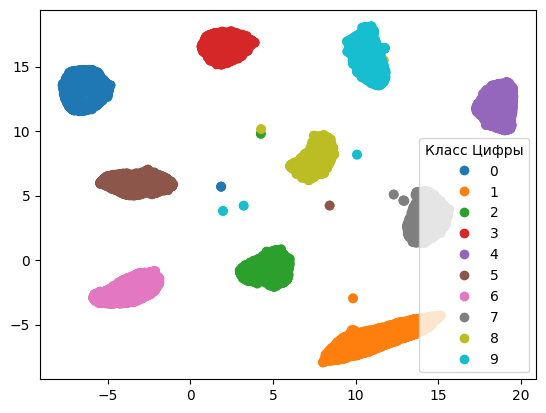

In [4]:
%matplotlib inline
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap='tab10')
handels, elemnts = scatter.legend_elements()
plt.legend(handels, elemnts, title='Класс Цифры')
plt.show()

In [5]:
lof = LocalOutlierFactor(n_neighbors=15, contamination=0.0015)
is_inliner = lof.fit_predict(X_reduced)
X_copy = X.copy()
X_copy['is_anomaly'] = is_inliner
anomalies = X_copy[X_copy['is_anomaly'] == -1]
print(len(anomalies))

90


In [6]:
first_row = X.iloc[1]
def to_image(str_img):
    return Image.fromarray(np.array(str_img,dtype=np.uint8).reshape((28,28)), mode='L')
image1 = to_image(first_row)

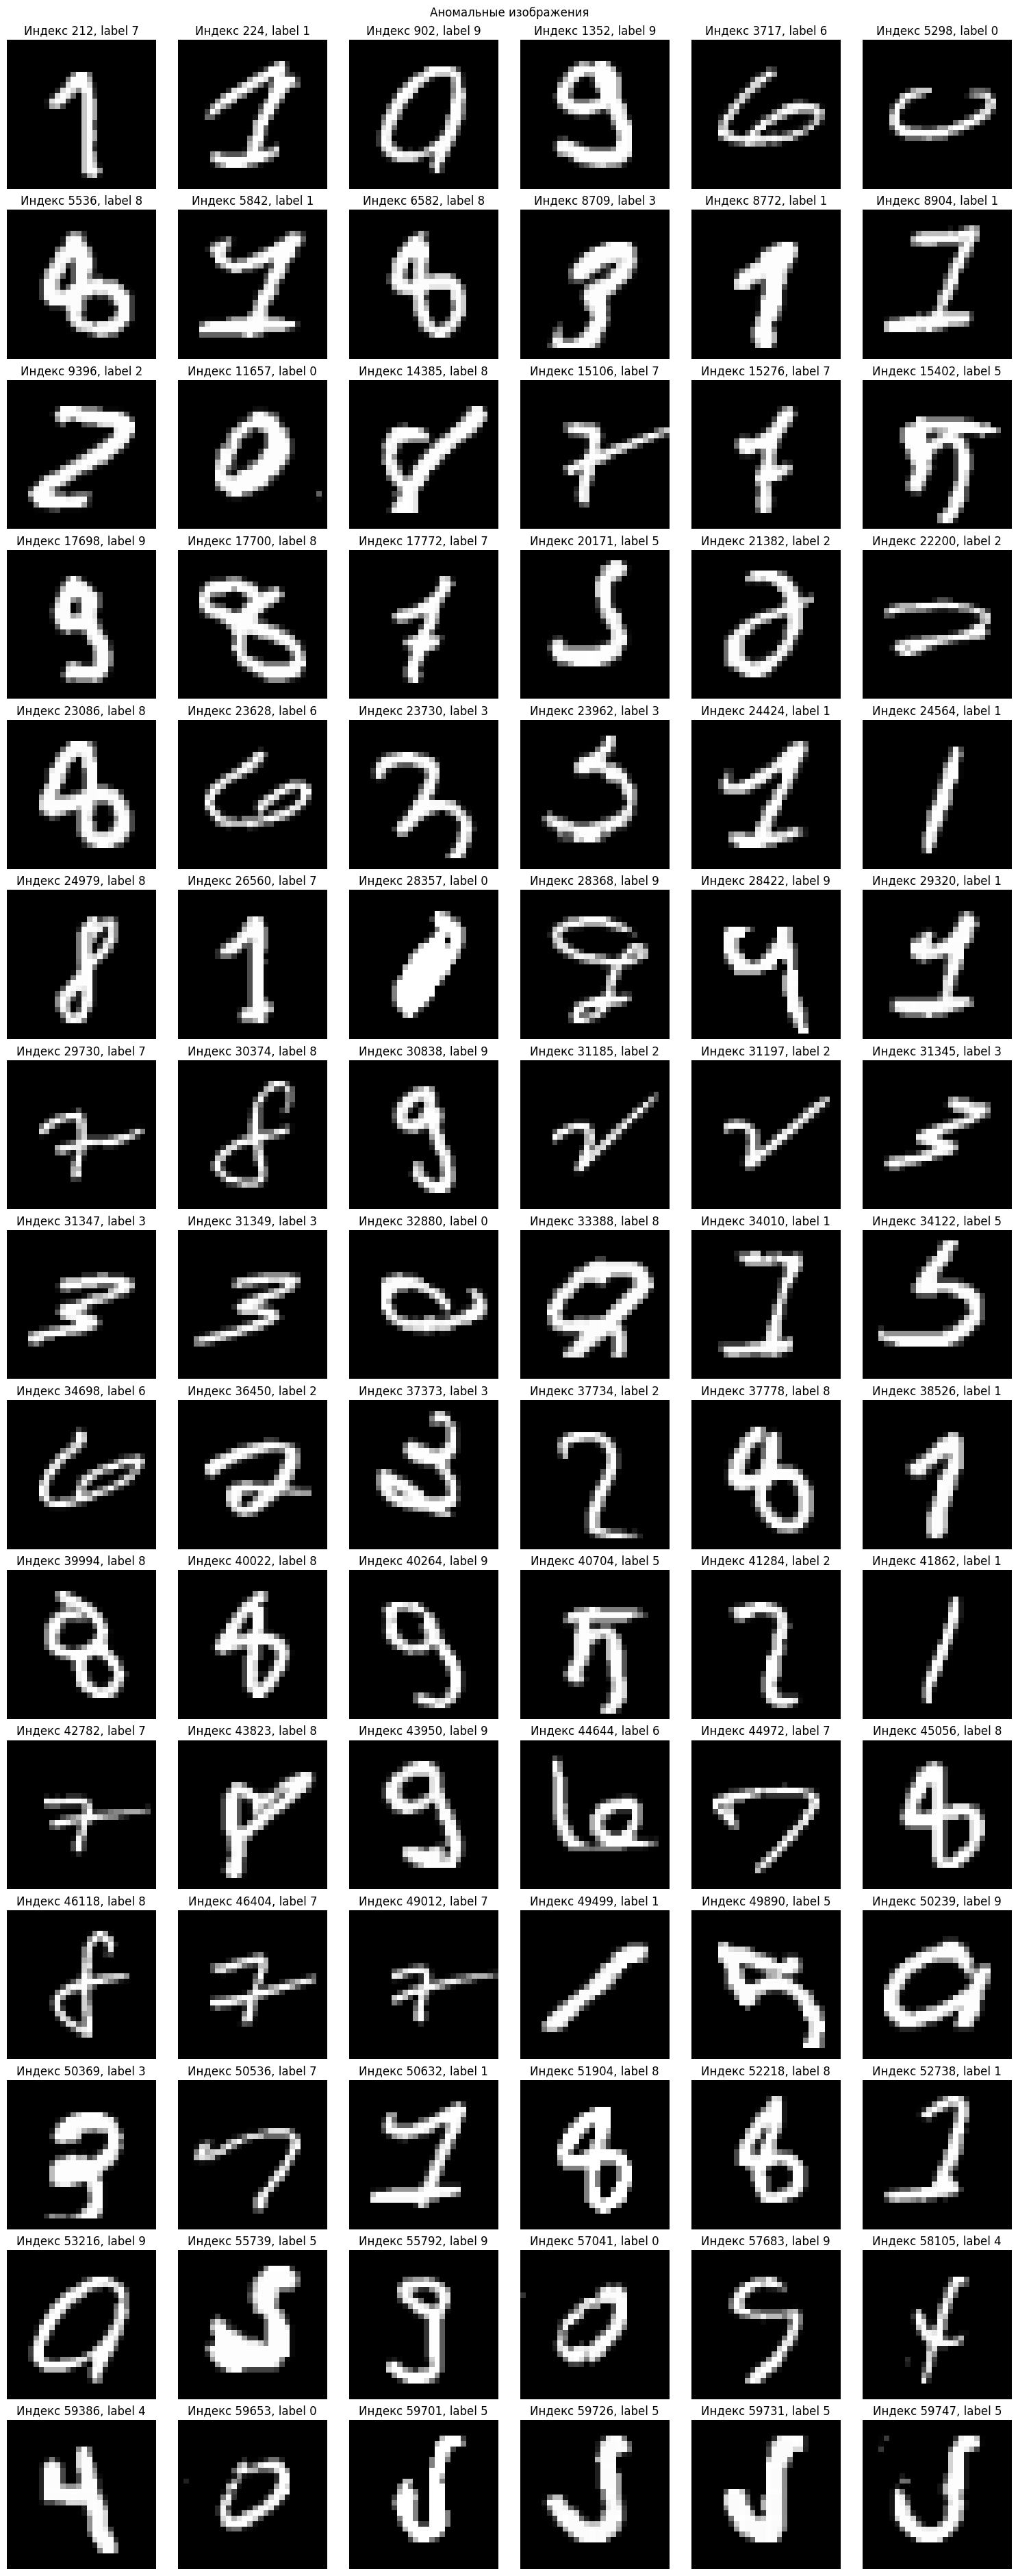

In [7]:
#fix here
show_anomalies = [
    to_image(anomalies.iloc[i].drop('is_anomaly'))
    for i in range(len(anomalies))
]

if not show_anomalies:
    print('Аномалии не найдены.')
else:
    columns = min(6, len(show_anomalies))
    rows = (len(show_anomalies) + columns - 1) // columns
    fig, axes = plt.subplots(
        rows, columns, figsize=(2.5 * columns, 2.5 * rows),
        squeeze=False, constrained_layout=True,
    )
    fig.suptitle('Аномальные изображения')
    for i, ax in enumerate(axes.flat):
        ax.axis('off')
        if i < len(show_anomalies):
            ax.imshow(show_anomalies[i], cmap='gray', vmin=0, vmax=255)
            ax.set_title(f'Индекс {anomalies.index[i]}, label {y.loc[anomalies.index[i]]}')
    plt.show()


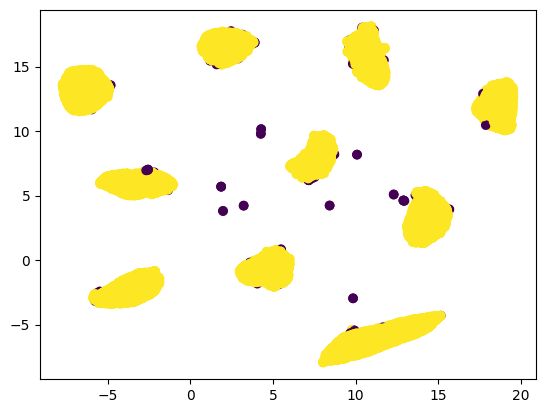

In [8]:
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=X_copy['is_anomaly'])

(60000, 2)


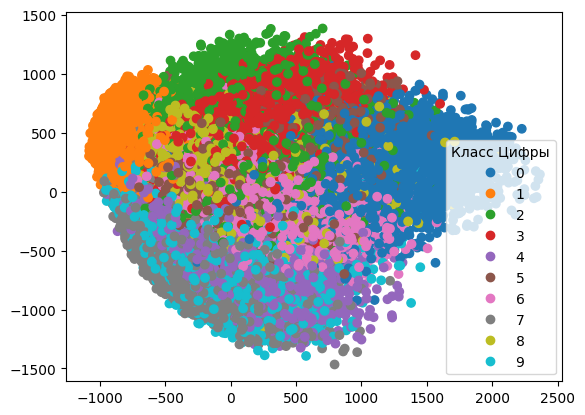

In [9]:
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X)
print(X_train_pca.shape)
scatter_pca = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y, cmap='tab10')
handels, elemnts = scatter_pca.legend_elements()
plt.legend(handels, elemnts, title='Класс Цифры')
plt.show()

In [10]:
from sklearn.manifold import TSNE
model = TSNE(n_components = 2, random_state = 42)

tsne_data = model.fit_transform(X)


(60000, 2)


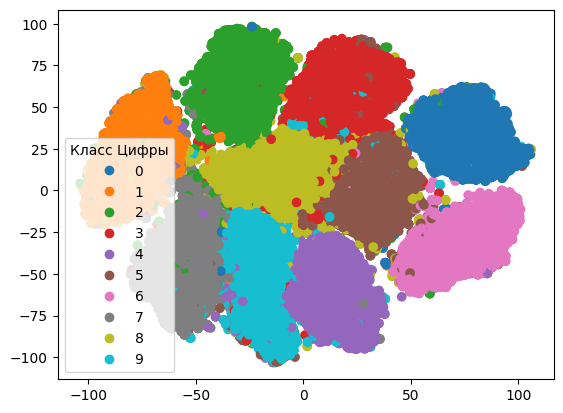

In [11]:
print(tsne_data.shape)
scatter_tsne = plt.scatter(tsne_data[:, 0], tsne_data[:, 1], c=y, cmap='tab10')
handels, elemnts = scatter_tsne.legend_elements()
plt.legend(handels, elemnts, title='Класс Цифры')
plt.show()

<Axes: >

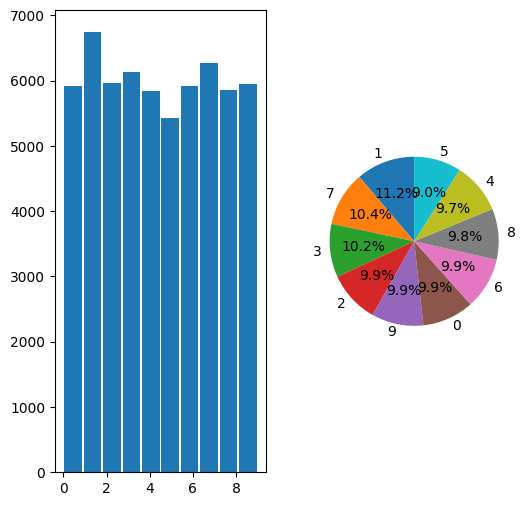

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6, 6))
ax[0].hist(images['label'], rwidth=0.9)
images['label'].value_counts().plot.pie(autopct='%1.1f%%', 
    startangle=90, 
    ylabel='')

In [13]:
counts = images['label'].value_counts()
imbalance_ratio = counts.max() / counts.min()
print('Коэффициент дисбаланса', imbalance_ratio)
print('Индекс Gini:', 1 - (images['label'].value_counts(normalize=True) ** 2).sum())

Коэффициент дисбаланса 1.243681977494927
Индекс Gini: 0.8997118405555555


In [14]:
# print(images[images['label'] == 4]['label'].count())
# print(images['label'].value_counts())
# images['label'].unique()


In [15]:
#make here 2
X_without_anomalies = X.drop(index=anomalies.index).copy()
y_without_anomalies = y.loc[X_without_anomalies.index].copy()

print(f'Удалено аномалий: {len(X) - len(X_without_anomalies)}')
print('Размеры без аномалий:', X_without_anomalies.shape, y_without_anomalies.shape)

from sklearn.model_selection import train_test_split

X_train_without_anomalies, X_val_without_anomalies, y_train_without_anomalies, y_val_without_anomalies = train_test_split(
    X_without_anomalies,
    y_without_anomalies,
    test_size=0.2,
    random_state=42,
    stratify=y_without_anomalies,
)

print('Train:', X_train_without_anomalies.shape, y_train_without_anomalies.shape)
print('Test:', X_val_without_anomalies.shape, y_val_without_anomalies.shape)


Удалено аномалий: 90
Размеры без аномалий: (59910, 784) (59910,)
Train: (47928, 784) (47928,)
Test: (11982, 784) (11982,)


In [16]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.utils import shuffle

need_to_over_smaple = {}
mdeian_count = y_train.value_counts().median()
val = y_train.unique().tolist()

need_to_under_smaple = {}
for i in val:
    need_to_under_smaple[i] = mdeian_count

rus = RandomUnderSampler(random_state=0)
X_resampled_un, y_resampled_un = rus.fit_resample(X_train, y_train)
print("После Undersampling:", Counter(y_resampled_un))

X_resampled_un, y_resampled_un = shuffle(
    X_resampled_un, y_resampled_un, random_state=42
)

После Undersampling: Counter({0: 4337, 1: 4337, 2: 4337, 3: 4337, 4: 4337, 5: 4337, 6: 4337, 7: 4337, 8: 4337, 9: 4337})


<Axes: >

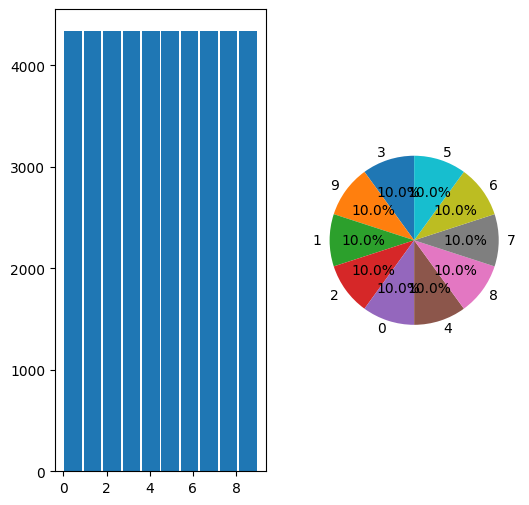

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6, 6))
ax[0].hist(y_resampled_un, rwidth=0.9)
y_resampled_un.value_counts().plot.pie(autopct='%1.1f%%', 
    startangle=90, 
    ylabel='')

In [18]:
counts = y_resampled_un.value_counts()
imbalance_ratio = counts.max() / counts.min()
print('Коэффициент дисбаланса', imbalance_ratio)
print('Индекс Gini:', 1 - (y_resampled_un.value_counts(normalize=True) ** 2).sum())

Коэффициент дисбаланса 1.0
Индекс Gini: 0.8999999999999999


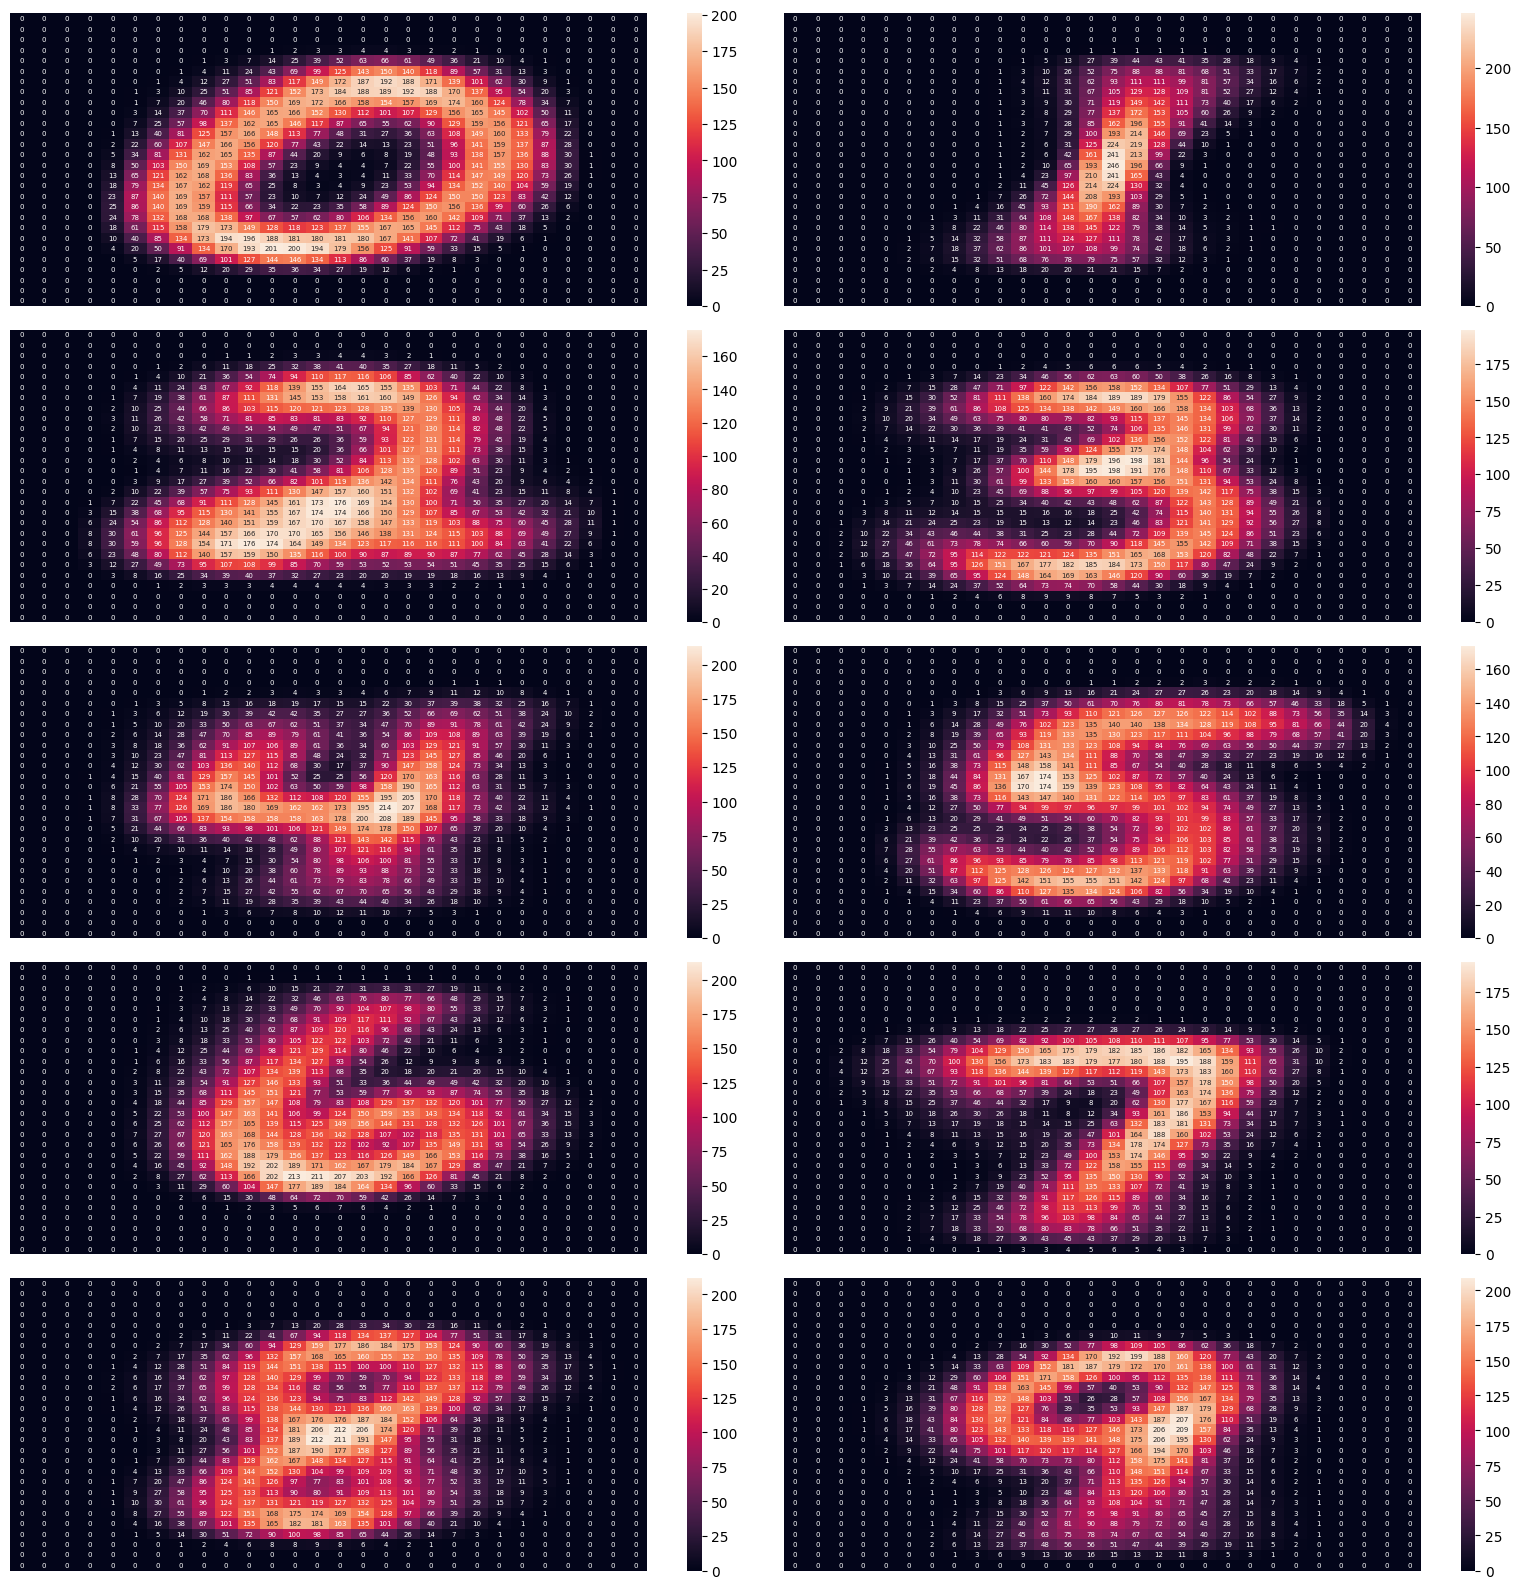

In [19]:
test = images.groupby('label').mean()
mean_img_classes = []
for i in range(len(test)):
    mean_img_classes.append(to_image(test.iloc[i]))


fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 16))
axes = axes.flatten()
for i, matrix in enumerate(mean_img_classes):
    sns.heatmap(matrix, ax=axes[i], annot=True, fmt="d",annot_kws={"size": 5})
    # axes[i].set_title(titles[i], fontsize=16, weight='bold', pad=15) # Заголовок для каждого графика
    axes[i].axis('off')
plt.tight_layout()


In [20]:
duplicates = images.duplicated()
print('Дубликаты изображений с одинаковыми метками: ', duplicates.sum())
duplicates_diff = X.duplicated()
print('Дубликаты изображений с разными метками: ', duplicates_diff.sum())
print('Диапазон значений: ', X.min().min(), X.max().max())


Дубликаты изображений с одинаковыми метками:  0
Дубликаты изображений с разными метками:  0
Диапазон значений:  0 255


In [21]:

class NeuralNetwork(nn.Module):
    def __init__(self, p_val, func='relu'):
        super().__init__()
        self.p_val = p_val
        self.l1 = nn.Linear(28*28, 64)
        self.l2 = nn.Linear(64, 10)
        self.drop = nn.Dropout(p_val)
        self.activation_func = nn.ReLU()
        if func == 'sigmoid':
            self.activation_func = nn.Sigmoid()

    def forward(self, x):
        x = self.drop(self.activation_func(self.l1(x)))
        # x = nn.functional.relu(self.l1(x))
        x = self.l2(x)
        return x


In [135]:
X_train.shape, y_val.shape, X_train_without_anomalies.shape, y_val_without_anomalies.shape, X_resampled_un.shape, X_val.shape

((48000, 784), (12000,), (47928, 784), (11982,), (43370, 784), (12000, 784))

In [136]:
def metrics_cals(y, labels):
    accuracy = accuracy_score(y, labels)
    precision_micro = precision_score(y, labels, average='micro')
    precision_macro = precision_score(y, labels, average='macro')
    recall_micro = recall_score(y, labels, average='micro')
    recall_macro = recall_score(y, labels, average='macro')
    f1_macro = f1_score(y, labels, average='macro')
    f1_micro = f1_score(y, labels, average='micro')
    return [accuracy, precision_micro, precision_macro, recall_micro, recall_macro, f1_micro, f1_macro]
    # return {'accuracy': accuracy,
    # 'precision_micro': precision_micro,
    # 'precision_macro': precision_macro,
    # 'recall_micro': recall_micro,
    # 'recall_macro': recall_macro,
    # 'f1_micro': f1_micro,
    # 'f1_macro': f1_macro,}


In [24]:
def mean_prediction_confidence(scores, y_true):
    scores = torch.as_tensor(scores).detach()
    if not scores.is_floating_point():
        scores = scores.float()
    y_true = torch.as_tensor(
        np.asarray(y_true) if not torch.is_tensor(y_true) else y_true,
        dtype=torch.long, device=scores.device,
    ).reshape(-1)
    probabilities = torch.softmax(scores, dim=1)
    confidence, predictions = probabilities.max(dim=1)
    correct = predictions.eq(y_true)
    return {
        "correct_mean_confidence": (
            confidence[correct].mean().item() if correct.any() else float("nan")
        ),
        "incorrect_mean_confidence": (
            confidence[~correct].mean().item() if (~correct).any() else float("nan")
        ),
        "correct_count": correct.sum().item(),
        "incorrect_count": (~correct).sum().item(),
    }


50890


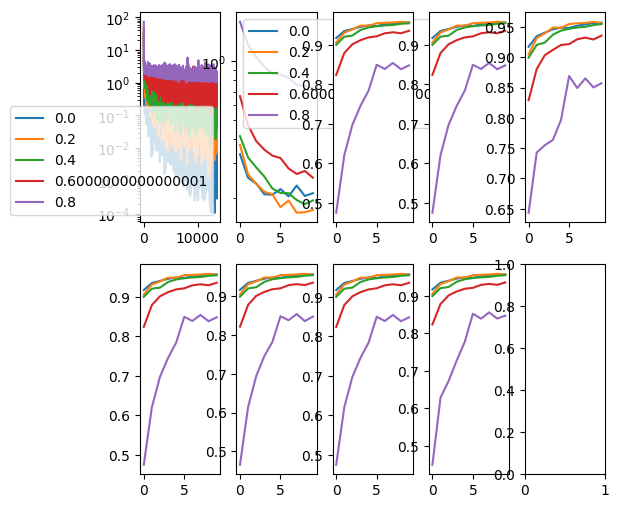

In [76]:
#Add here 11
import random
import numpy as np
import torch

SEED = 6
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

BATCH_SIZE = 32
EPOCHS = 10
val_label = []
models_with_different_p_balanced = []
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(6, 6))
for p_val in range(0, 10, 2):
    model = NeuralNetwork(p_val * 0.1)
    opt = torch.optim.Adam(model.parameters(), lr=3e-4)
    loss_func = nn.CrossEntropyLoss()
    losses = []
    save_metrics_resampled = []
    val_loss = []
    for j in range(EPOCHS):
        val_label = []
        labels = []
        model.train()
        for i in range(0, len(X_resampled_un), BATCH_SIZE):
            outputs = model(torch.Tensor(np.array(X_resampled_un[i:i+BATCH_SIZE], dtype=np.float32)))
            # print(outputs)
            labels += torch.argmax(outputs.detach(), dim=1)
            loss = loss_func(outputs, torch.tensor(np.array(y_resampled_un[i:i+BATCH_SIZE]), dtype=torch.long))
            loss.backward()
            opt.step()
            model.zero_grad()
            losses.append(loss.item())
        save_loss_val = []
        model.eval()
        with torch.no_grad():
            for i in range(0, len(X_val), BATCH_SIZE):
                outputs = model(torch.Tensor(np.array(X_val[i:i+BATCH_SIZE], dtype=np.float32)))
                # print(outputs)
                val_label += torch.argmax(outputs.detach(), dim=1)
                loss = loss_func(outputs, torch.tensor(np.array(y_val[i:i+BATCH_SIZE]), dtype=torch.long))
                save_loss_val.append(loss.item())
            val_loss.append(torch.tensor(save_loss_val).mean())
            save_metrics_resampled.append(metrics_cals(y_val, val_label))
    
    save_metrics_resampled = np.array(save_metrics_resampled)
    for metrics_plot in range(2, 9):
            # print(metrics_plot, metrics_plot//5, metrics_plot % 5)
            axes[metrics_plot//5][metrics_plot % 5].plot(save_metrics_resampled[:, metrics_plot - 2])
    models_with_different_p_balanced.append(model)

            
    axes[0][0].plot(losses, label=f'{p_val * 0.1}')
    axes[0][1].plot(val_loss, label=f'{p_val * 0.1}')
    
axes[0][0].legend()
axes[0][1].legend()
axes[0][0].set_yscale('log')
axes[0][1].set_yscale('log')

print(sum(p.numel() for p in model.parameters()))
plt.show()


In [121]:

for j, model_p in enumerate(models_with_different_p_balanced):
    metrics_test_labels = []
    conf = torch.tensor([])
    for i in range(0, len(X_test), BATCH_SIZE):
        outputs = model_p(torch.Tensor(np.array(X_test[i:i+BATCH_SIZE], dtype=np.float32)))
        # print(outputs)
        metrics_test_labels += torch.argmax(outputs.detach(), dim=1)
        conf = torch.cat((conf, outputs))
    # print(, end=' ')
    print(f'metrivs for p = {j * 0.2}', mean_prediction_confidence(conf, y_test),metrics_cals(y_test, metrics_test_labels))

    


metrivs for p = 0.0 {'correct_mean_confidence': 0.9892167448997498, 'incorrect_mean_confidence': 0.812982439994812, 'correct_count': 9603, 'incorrect_count': 397} {'accuracy': 0.9603, 'precision_micro': 0.9603, 'precision_macro': 0.9603477823470759, 'recall_micro': 0.9603, 'recall_macro': 0.959862704307865, 'f1_micro': 0.9603, 'f1_macro': 0.9599862701228122}
metrivs for p = 0.2 {'correct_mean_confidence': 0.9811474680900574, 'incorrect_mean_confidence': 0.7233063578605652, 'correct_count': 9555, 'incorrect_count': 445} {'accuracy': 0.9555, 'precision_micro': 0.9555, 'precision_macro': 0.9551829560351461, 'recall_micro': 0.9555, 'recall_macro': 0.9551708565303961, 'f1_micro': 0.9555, 'f1_macro': 0.9549040630868989}
metrivs for p = 0.4 {'correct_mean_confidence': 0.9736961126327515, 'incorrect_mean_confidence': 0.6875988245010376, 'correct_count': 9535, 'incorrect_count': 465} {'accuracy': 0.9535, 'precision_micro': 0.9535, 'precision_macro': 0.9530672860226428, 'recall_micro': 0.9535, '

metrivs for p = 0.2 {'accuracy': 0.9603, 'precision_micro': 0.9603, 'precision_macro': 0.9603477823470759, 'recall_micro': 0.9603, 'recall_macro': 0.959862704307865, 'f1_micro': 0.9603, 'f1_macro': 0.9599862701228122}


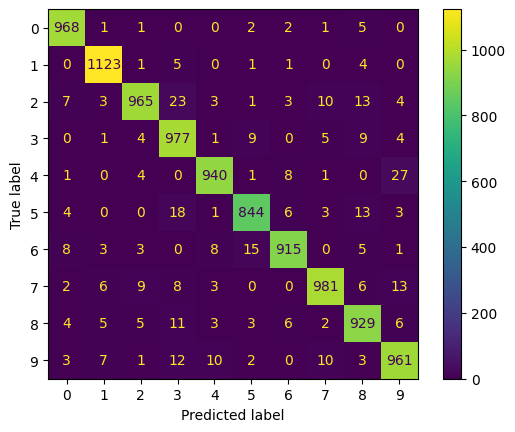

In [118]:
metrics_test_labels = []
for i in range(0, len(X_test), BATCH_SIZE):
    outputs = models_with_different_p_balanced[0](torch.Tensor(np.array(X_test[i:i+BATCH_SIZE], dtype=np.float32)))
    # print(outputs)
    metrics_test_labels += torch.argmax(outputs.detach(), dim=1)
print(f'metrivs for p = {0.2}', metrics_cals(y_test, metrics_test_labels))

cm = confusion_matrix(y_test, metrics_test_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


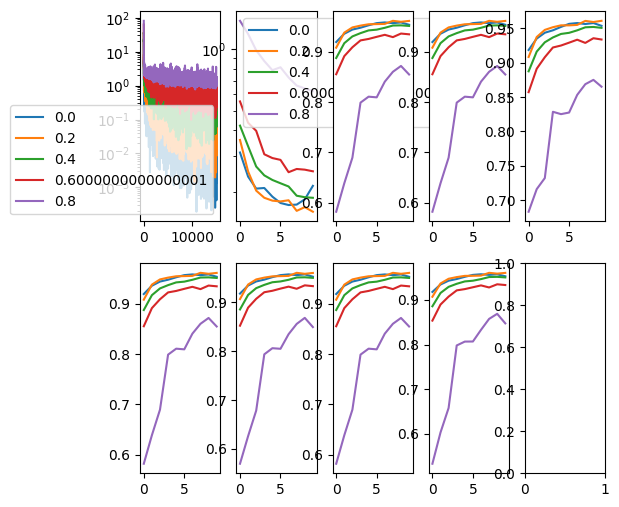

In [79]:
#Add here 11
import random
import numpy as np
import torch

SEED = 6
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

BATCH_SIZE = 32
EPOCHS = 10
val_label = []
models_with_different_p = []
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(6, 6))
for p_val in range(0, 10, 2):
    model = NeuralNetwork(p_val * 0.1)
    opt = torch.optim.Adam(model.parameters(), lr=3e-4)
    loss_func = nn.CrossEntropyLoss()
    losses = []
    save_metrics = []
    val_loss = []
    for j in range(EPOCHS):
        val_label = []
        labels = []
        model.train()
        for i in range(0, len(X_train), BATCH_SIZE):
            outputs = model(torch.Tensor(np.array(X_train[i:i+BATCH_SIZE], dtype=np.float32)))
            # print(outputs)
            labels += torch.argmax(outputs.detach(), dim=1)
            loss = loss_func(outputs, torch.tensor(np.array(y_train[i:i+BATCH_SIZE]), dtype=torch.long))
            loss.backward()
            opt.step()
            model.zero_grad()
            losses.append(loss.item())
        save_loss_val = []
        model.eval()
        with torch.no_grad():
            for i in range(0, len(X_val), BATCH_SIZE):
                outputs = model(torch.Tensor(np.array(X_val[i:i+BATCH_SIZE], dtype=np.float32)))
                # print(outputs)
                val_label += torch.argmax(outputs.detach(), dim=1)
                loss = loss_func(outputs, torch.tensor(np.array(y_val[i:i+BATCH_SIZE]), dtype=torch.long))
                save_loss_val.append(loss.item())
            val_loss.append(torch.tensor(save_loss_val).mean())
            save_metrics.append(metrics_cals(y_val, val_label))
    save_metrics = np.array(save_metrics)
    # print(save_metrics)
    for metrics_plot in range(2, 9):
        # print(metrics_plot, metrics_plot//5, metrics_plot % 5)
        axes[metrics_plot//5][metrics_plot % 5].plot(save_metrics[:, metrics_plot - 2])
    models_with_different_p.append(model)

            
    axes[0][0].plot(losses, label=f'{p_val * 0.1}')
    axes[0][1].plot(val_loss, label=f'{p_val * 0.1}')
    
axes[0][0].legend()
axes[0][1].legend()
axes[0][0].set_yscale('log')
axes[0][1].set_yscale('log')
plt.show()


In [124]:
for j, model_p in enumerate(models_with_different_p):
    metrics_test_labels = []
    conf = torch.tensor([])
    for i in range(0, len(X_test), BATCH_SIZE):
        outputs = model_p(torch.Tensor(np.array(X_test[i:i+BATCH_SIZE], dtype=np.float32)))
        # print(outputs)
        metrics_test_labels += torch.argmax(outputs.detach(), dim=1)
        conf = torch.cat((conf, outputs))
    # print(mean_prediction_confidence(conf, y_test), end=' ')
    print(f'metrivs for p = {j * 0.1}', mean_prediction_confidence(conf, y_test), metrics_cals(y_test, metrics_test_labels))



metrivs for p = 0.0 {'correct_mean_confidence': 0.9861805438995361, 'incorrect_mean_confidence': 0.7808266282081604, 'correct_count': 9514, 'incorrect_count': 486} {'accuracy': 0.9514, 'precision_micro': 0.9514, 'precision_macro': 0.9516730968458533, 'recall_micro': 0.9514, 'recall_macro': 0.9512513107091838, 'f1_micro': 0.9514, 'f1_macro': 0.9511257821812835}
metrivs for p = 0.1 {'correct_mean_confidence': 0.9778470993041992, 'incorrect_mean_confidence': 0.7281354665756226, 'correct_count': 9613, 'incorrect_count': 387} {'accuracy': 0.9613, 'precision_micro': 0.9613, 'precision_macro': 0.9609556793840077, 'recall_micro': 0.9613, 'recall_macro': 0.9609917478180685, 'f1_micro': 0.9613, 'f1_macro': 0.9608868402058507}
metrivs for p = 0.2 {'correct_mean_confidence': 0.964920699596405, 'incorrect_mean_confidence': 0.6566575169563293, 'correct_count': 9531, 'incorrect_count': 469} {'accuracy': 0.9531, 'precision_micro': 0.9531, 'precision_macro': 0.9524909115589153, 'recall_micro': 0.9531, 

metrivs for p = 0.2 {'accuracy': 0.9613, 'precision_micro': 0.9613, 'precision_macro': 0.9609556793840077, 'recall_micro': 0.9613, 'recall_macro': 0.9609917478180685, 'f1_micro': 0.9613, 'f1_macro': 0.9608868402058507}


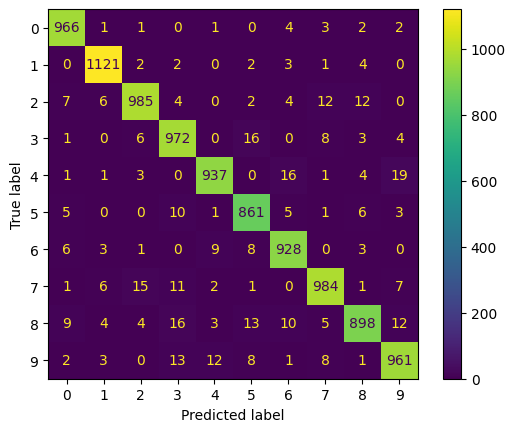

In [125]:
metrics_test_labels = []
for i in range(0, len(X_test), BATCH_SIZE):
    outputs = models_with_different_p[1](torch.Tensor(np.array(X_test[i:i+BATCH_SIZE], dtype=np.float32)))
    # print(outputs)
    metrics_test_labels += torch.argmax(outputs.detach(), dim=1)
print(f'metrivs for p = {0.2}', metrics_cals(y_test, metrics_test_labels))

cm = confusion_matrix(y_test, metrics_test_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


[0.8994166666666666, 0.8994166666666666, 0.8986040614591644, 0.8994166666666666, 0.8978687685164509, 0.8994166666666666, 0.8978572163589549]
[0.9128333333333334, 0.9128333333333334, 0.9121483706728263, 0.9128333333333334, 0.9115655468764002, 0.9128333333333334, 0.9115034995823391]
[0.9181666666666667, 0.9181666666666667, 0.9173419804521934, 0.9181666666666667, 0.9172324278145091, 0.9181666666666667, 0.9172115465830444]
[0.9195833333333333, 0.9195833333333333, 0.9199471529499437, 0.9195833333333333, 0.9188330181512259, 0.9195833333333333, 0.9189649259288887]
[0.91475, 0.91475, 0.9146143259439926, 0.91475, 0.9136059705045382, 0.91475, 0.9136269797225708]
[0.9260833333333334, 0.9260833333333334, 0.9251386866724426, 0.9260833333333334, 0.9253593107432069, 0.9260833333333334, 0.9250922539944298]
[0.9276666666666666, 0.9276666666666666, 0.9269561659187378, 0.9276666666666666, 0.9272836851575414, 0.9276666666666666, 0.926855975259161]
[0.9285, 0.9285, 0.9281056126156766, 0.9285, 0.92806090699

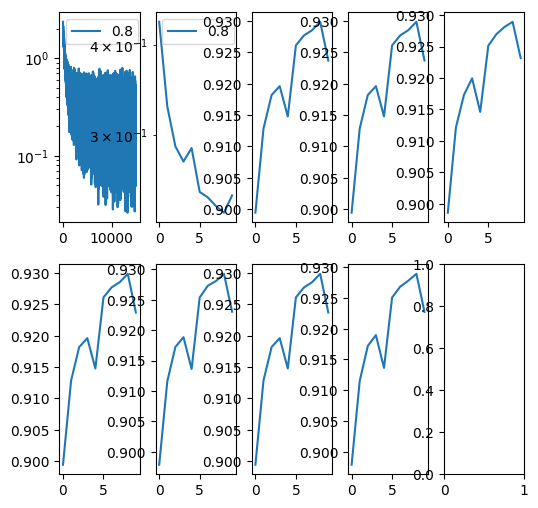

In [82]:
#Add here 11
import random
import numpy as np
import torch

SEED = 6
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

BATCH_SIZE = 32
EPOCHS = 10
val_label = []
models_with_different_p_sigmoid = []
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(6, 6))
model = NeuralNetwork(0.0, 'sigmoid')
opt = torch.optim.Adam(model.parameters(), lr=3e-4)
loss_func = nn.CrossEntropyLoss()
losses = []
save_metrics_sigmoid = []
val_loss = []
for j in range(EPOCHS):
    val_label = []
    labels = []
    model.train()
    for i in range(0, len(X_train), BATCH_SIZE):
        outputs = model(torch.Tensor(np.array(X_train[i:i+BATCH_SIZE], dtype=np.float32)))
        # print(outputs)
        labels += torch.argmax(outputs.detach(), dim=1)
        loss = loss_func(outputs, torch.tensor(np.array(y_train[i:i+BATCH_SIZE]), dtype=torch.long))
        loss.backward()
        opt.step()
        model.zero_grad()
        losses.append(loss.item())
    save_loss_val = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(X_val), BATCH_SIZE):
            outputs = model(torch.Tensor(np.array(X_val[i:i+BATCH_SIZE], dtype=np.float32)))
            # print(outputs)
            val_label += torch.argmax(outputs.detach(), dim=1)
            loss = loss_func(outputs, torch.tensor(np.array(y_val[i:i+BATCH_SIZE]), dtype=torch.long))
            save_loss_val.append(loss.item())
        val_loss.append(torch.tensor(save_loss_val).mean())
        print(metrics_cals(y_val, val_label))
        save_metrics_sigmoid.append(metrics_cals(y_val, val_label))
save_metrics_sigmoid = np.array(save_metrics_sigmoid)
# print(save_metrics)
for metrics_plot in range(2, 9):
    # print(metrics_plot, metrics_plot//5, metrics_plot % 5)
    axes[metrics_plot//5][metrics_plot % 5].plot(save_metrics_sigmoid[:, metrics_plot - 2])
models_with_different_p_sigmoid.append(model)

        
axes[0][0].plot(losses, label=f'{p_val * 0.1}')
axes[0][1].plot(val_loss, label=f'{p_val * 0.1}')
    
axes[0][0].legend()
axes[0][1].legend()
axes[0][0].set_yscale('log')
axes[0][1].set_yscale('log')
plt.show()


metrivs for p = 0.0 {'correct_mean_confidence': 0.9299197793006897, 'incorrect_mean_confidence': 0.6222457885742188, 'correct_count': 9275, 'incorrect_count': 725} {'accuracy': 0.9275, 'precision_micro': 0.9275, 'precision_macro': 0.9270202198302906, 'recall_micro': 0.9275, 'recall_macro': 0.9268759417264505, 'f1_micro': 0.9275, 'f1_macro': 0.9264878061142261}


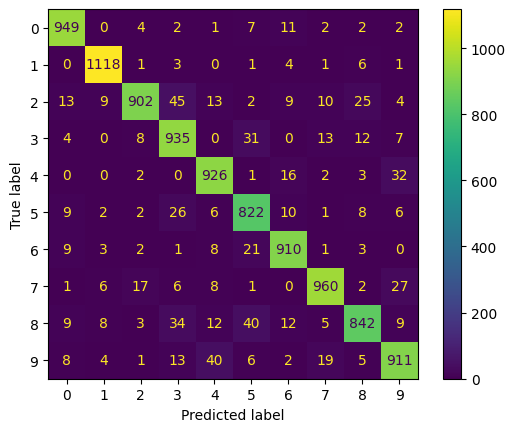

In [130]:
metrics_test_labels = []
conf = torch.tensor([])
for i in range(0, len(X_test), BATCH_SIZE):
    outputs = models_with_different_p_sigmoid[0](torch.Tensor(np.array(X_test[i:i+BATCH_SIZE], dtype=np.float32)))
    # print(outputs)
    metrics_test_labels += torch.argmax(outputs.detach(), dim=1)
    conf = torch.cat((conf, outputs))
# print(mean_prediction_confidence(conf, y_test), end=' ')    
print(f'metrivs for p = {0.0}', mean_prediction_confidence(conf, y_test), metrics_cals(y_test, metrics_test_labels))

cm = confusion_matrix(y_test, metrics_test_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

[0.9202136538140544, 0.9202136538140544, 0.9203592601506545, 0.9202136538140544, 0.9192727373333496, 0.9202136538140544, 0.9192686001414911]
[0.9328993490235353, 0.9328993490235353, 0.9328381186562673, 0.9328993490235353, 0.9322454093963437, 0.9328993490235353, 0.9322284159544223]
[0.9439993323318311, 0.9439993323318311, 0.9440963909356059, 0.9439993323318311, 0.9434145622248449, 0.9439993323318311, 0.9435054812355785]
[0.9520948088799867, 0.9520948088799867, 0.9520451170101518, 0.9520948088799867, 0.9514871816072793, 0.9520948088799867, 0.9516175569469884]
[0.9554331497245869, 0.9554331497245869, 0.9556244533265055, 0.9554331497245869, 0.9549931759974287, 0.9554331497245869, 0.9551412122209667]
[0.9545985645134368, 0.9545985645134368, 0.954795311218019, 0.9545985645134368, 0.9539258249254594, 0.9545985645134368, 0.9542099614398651]
[0.9543481889500918, 0.9543481889500918, 0.954822089554105, 0.9543481889500918, 0.9536071614364307, 0.9543481889500918, 0.9539385990437083]
[0.957769988315

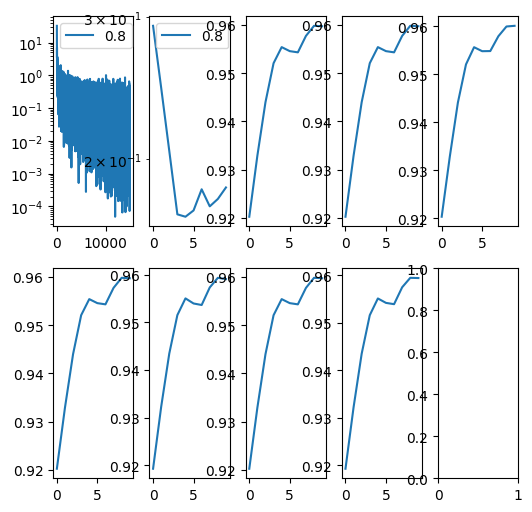

In [84]:
#Add here 11
import random
import numpy as np
import torch

SEED = 6
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

BATCH_SIZE = 32
EPOCHS = 10
val_label = []
models_with_different_p_clean = []
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(6, 6))
model = NeuralNetwork(0.0, 'relu')
opt = torch.optim.Adam(model.parameters(), lr=3e-4)
loss_func = nn.CrossEntropyLoss()
losses = []
save_metrics_clean = []
val_loss = []
for j in range(EPOCHS):
    val_label = []
    labels = []
    model.train()
    for i in range(0, len(X_train_without_anomalies), BATCH_SIZE):
        outputs = model(torch.Tensor(np.array(X_train_without_anomalies[i:i+BATCH_SIZE], dtype=np.float32)))
        # print(outputs)
        labels += torch.argmax(outputs.detach(), dim=1)
        loss = loss_func(outputs, torch.tensor(np.array(y_train_without_anomalies[i:i+BATCH_SIZE]), dtype=torch.long))
        loss.backward()
        opt.step()
        model.zero_grad()
        losses.append(loss.item())
    save_loss_val = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(X_val_without_anomalies), BATCH_SIZE):
            outputs = model(torch.Tensor(np.array(X_val_without_anomalies[i:i+BATCH_SIZE], dtype=np.float32)))
            # print(outputs)
            val_label += torch.argmax(outputs.detach(), dim=1)
            loss = loss_func(outputs, torch.tensor(np.array(y_val_without_anomalies[i:i+BATCH_SIZE]), dtype=torch.long))
            save_loss_val.append(loss.item())
        val_loss.append(torch.tensor(save_loss_val).mean())
        print(metrics_cals(y_val_without_anomalies, val_label))
        save_metrics_clean.append(metrics_cals(y_val_without_anomalies, val_label))
save_metrics_clean = np.array(save_metrics_clean)
# print(save_metrics)
for metrics_plot in range(2, 9):
    # print(metrics_plot, metrics_plot//5, metrics_plot % 5)
    axes[metrics_plot//5][metrics_plot % 5].plot(save_metrics_clean[:, metrics_plot - 2])
models_with_different_p_clean.append(model)

        
axes[0][0].plot(losses, label=f'{p_val * 0.1}')
axes[0][1].plot(val_loss, label=f'{p_val * 0.1}')
    
axes[0][0].legend()
axes[0][1].legend()
axes[0][0].set_yscale('log')
axes[0][1].set_yscale('log')
plt.show()


metrivs for p = 0.0 {'correct_mean_confidence': 0.9900538921356201, 'incorrect_mean_confidence': 0.8172112703323364, 'correct_count': 9609, 'incorrect_count': 391} {'accuracy': 0.9609, 'precision_micro': 0.9609, 'precision_macro': 0.9617060617684785, 'recall_micro': 0.9609, 'recall_macro': 0.9601243959724947, 'f1_micro': 0.9609, 'f1_macro': 0.9606661562067658}


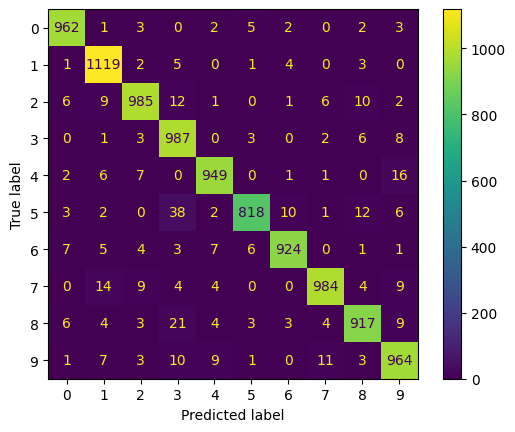

In [129]:
metrics_test_labels = []
conf = torch.tensor([])
for i in range(0, len(X_test), BATCH_SIZE):
    outputs = models_with_different_p_clean[0](torch.Tensor(np.array(X_test[i:i+BATCH_SIZE], dtype=np.float32)))
    # print(outputs)
    metrics_test_labels += torch.argmax(outputs.detach(), dim=1)
    conf = torch.cat((conf, outputs))
# print(mean_prediction_confidence(conf, y_test), end=' ')    
print(f'metrivs for p = {0.0}',mean_prediction_confidence(conf, y_test),  metrics_cals(y_test, metrics_test_labels))

cm = confusion_matrix(y_test, metrics_test_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [112]:
sum(p.numel() for p in models_with_different_p[1].parameters() if p.requires_grad)

50890

In [106]:
def vector_to_image_dim(vector_data, size_m, i, mode='single'):
    if mode == 'single':
        neuron_vector = vector_data[i].detach().cpu().numpy()
    elif mode == 'mean':
        neuron_vector = vector_data.mean(dim=0).detach().cpu().numpy()

    spatial_map = neuron_vector.reshape(1, size_m, size_m)
    heatmap2d = np.mean(spatial_map, axis=0)

    heatmap2d = (heatmap2d - heatmap2d.min()) / (
        heatmap2d.max() - heatmap2d.min() + 1e-8
    )
    return heatmap2d


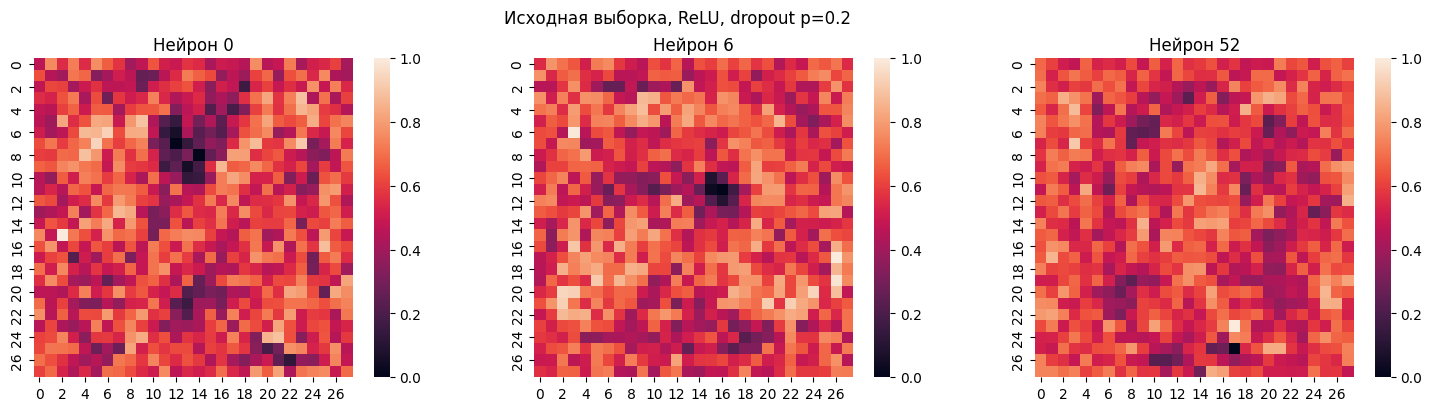

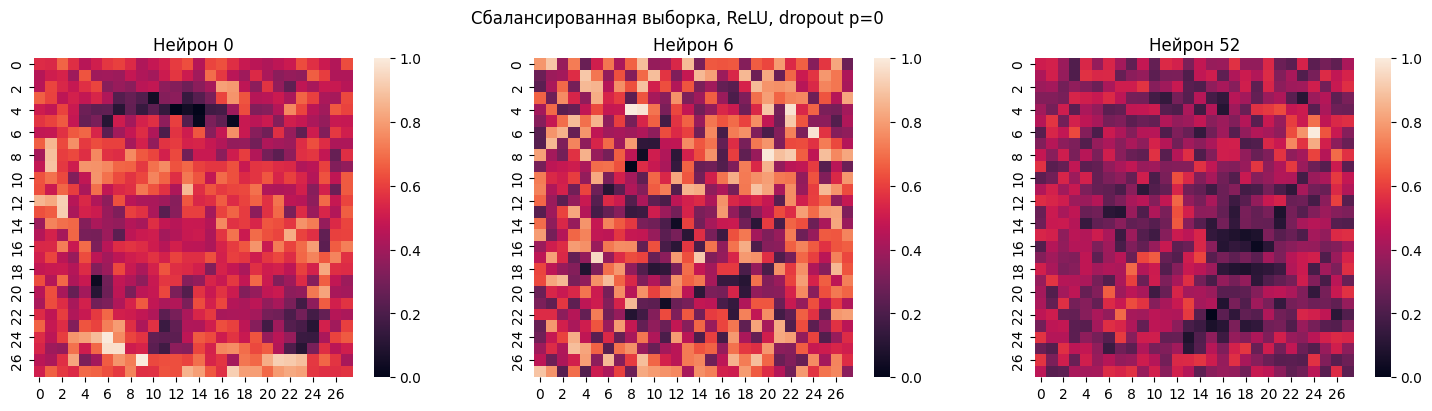

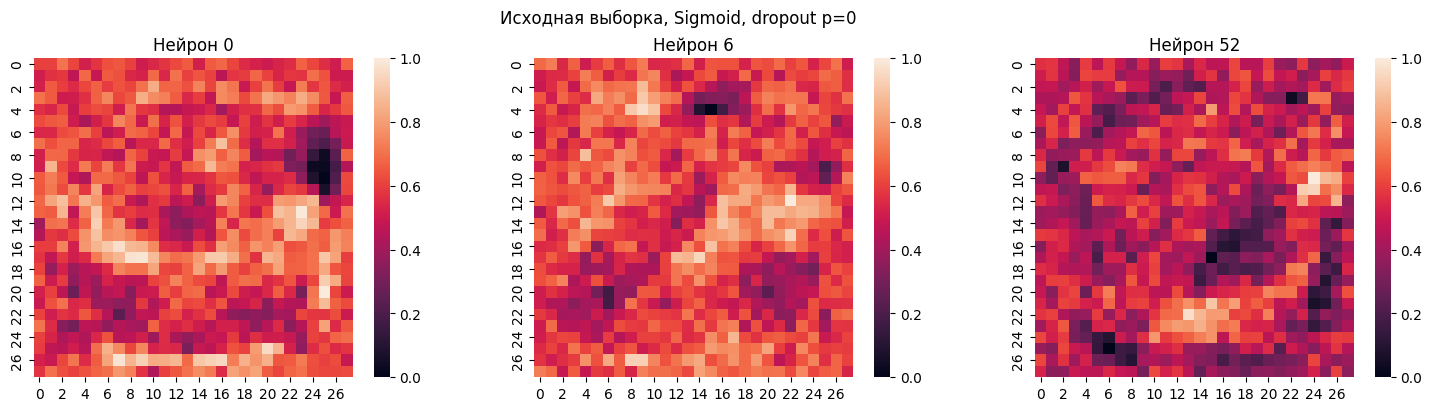

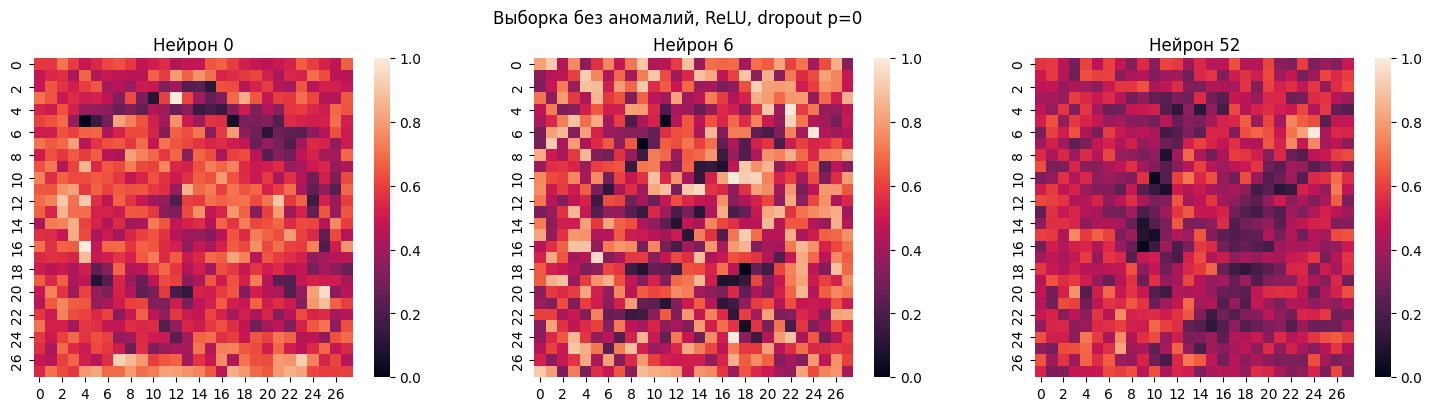

In [102]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
heatmap_model = models_with_different_p[1]
model_title = (f'Исходная выборка, {type(heatmap_model.activation_func).__name__}, '
               f'dropout p={heatmap_model.drop.p:g}')
for ax, neuron_index in zip(axes, (0, 6, 52)):
    heatmap = vector_to_image_dim(heatmap_model.l1.weight, 28, neuron_index)
    sns.heatmap(heatmap, ax=ax, square=True, vmin=0, vmax=1)
    ax.set_title(f'Нейрон {neuron_index}')
fig.suptitle(model_title)


fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
heatmap_model = models_with_different_p_balanced[0]
model_title = (f'Сбалансированная выборка, {type(heatmap_model.activation_func).__name__}, '
               f'dropout p={heatmap_model.drop.p:g}')
for ax, neuron_index in zip(axes, (0, 6, 52)):
    heatmap = vector_to_image_dim(heatmap_model.l1.weight, 28, neuron_index)
    sns.heatmap(heatmap, ax=ax, square=True, vmin=0, vmax=1)
    ax.set_title(f'Нейрон {neuron_index}')
fig.suptitle(model_title)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
heatmap_model = models_with_different_p_sigmoid[0]
model_title = (f'Исходная выборка, {type(heatmap_model.activation_func).__name__}, '
               f'dropout p={heatmap_model.drop.p:g}')
for ax, neuron_index in zip(axes, (0, 6, 52)):
    heatmap = vector_to_image_dim(heatmap_model.l1.weight, 28, neuron_index)
    sns.heatmap(heatmap, ax=ax, square=True, vmin=0, vmax=1)
    ax.set_title(f'Нейрон {neuron_index}')
fig.suptitle(model_title)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
heatmap_model = models_with_different_p_clean[0]
model_title = (f'Выборка без аномалий, {type(heatmap_model.activation_func).__name__}, '
               f'dropout p={heatmap_model.drop.p:g}')
for ax, neuron_index in zip(axes, (0, 6, 52)):
    heatmap = vector_to_image_dim(heatmap_model.l1.weight, 28, neuron_index)
    sns.heatmap(heatmap, ax=ax, square=True, vmin=0, vmax=1)
    ax.set_title(f'Нейрон {neuron_index}')
fig.suptitle(model_title)
plt.show()

Text(0.5, 0.98, 'Средняя тепловая карта весов нейронов')

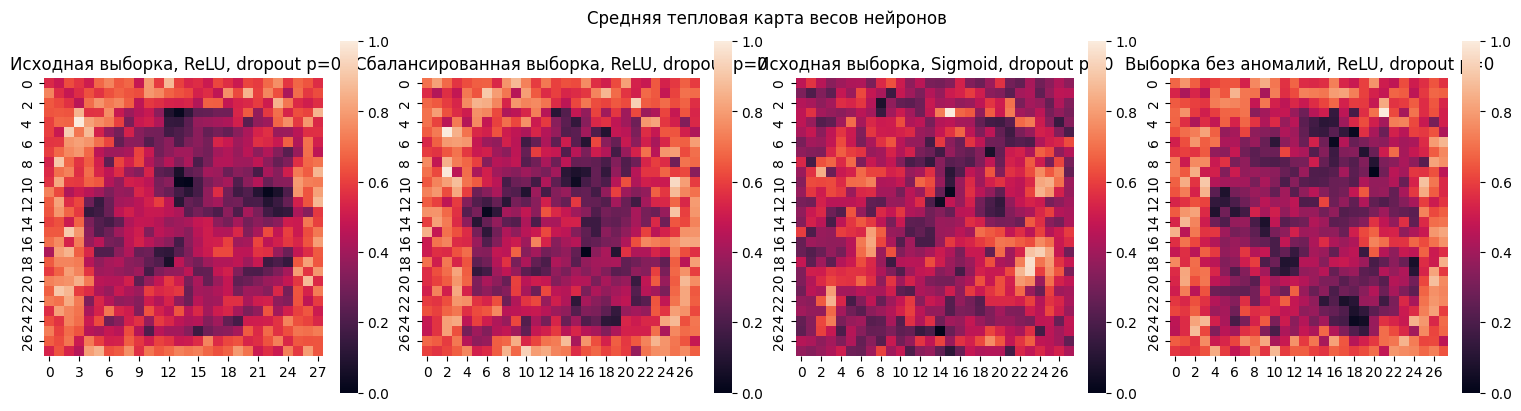

In [110]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4), constrained_layout=True)
heatmap_model = models_with_different_p[1]
model_title = (f'Исходная выборка, {type(heatmap_model.activation_func).__name__}, '
               f'dropout p={heatmap_model.drop.p:g}')
heatmap = vector_to_image_dim(heatmap_model.l1.weight, 28, neuron_index, 'mean')
sns.heatmap(heatmap, ax=axes[0], square=True, vmin=0, vmax=1)
axes[0].set_title(f'Исходная выборка, {type(heatmap_model.activation_func).__name__}, '
               f'dropout p={heatmap_model.drop.p:g}')
fig.suptitle(model_title)

heatmap_model = models_with_different_p_balanced[0]
model_title = (f'Сбалансированная выборка, {type(heatmap_model.activation_func).__name__}, '
               f'dropout p={heatmap_model.drop.p:g}')
heatmap = vector_to_image_dim(heatmap_model.l1.weight, 28, neuron_index, 'mean')
sns.heatmap(heatmap, ax=axes[1], square=True, vmin=0, vmax=1)
axes[1].set_title(f'Сбалансированная выборка, {type(heatmap_model.activation_func).__name__}, '
               f'dropout p={heatmap_model.drop.p:g}')
fig.suptitle(model_title)

heatmap_model = models_with_different_p_sigmoid[0]
model_title = (f'Исходная выборка, {type(heatmap_model.activation_func).__name__}, '
               f'dropout p={heatmap_model.drop.p:g}')
heatmap = vector_to_image_dim(heatmap_model.l1.weight, 28, neuron_index, 'mean')
sns.heatmap(heatmap, ax=axes[2], square=True, vmin=0, vmax=1)
axes[2].set_title(f'Исходная выборка, {type(heatmap_model.activation_func).__name__}, '
               f'dropout p={heatmap_model.drop.p:g}')
fig.suptitle(model_title)

heatmap_model = models_with_different_p_clean[0]
model_title = (f'Средняя тепловая карта весов нейронов')
heatmap = vector_to_image_dim(heatmap_model.l1.weight, 28, neuron_index, 'mean')
sns.heatmap(heatmap, ax=axes[3], square=True, vmin=0, vmax=1)
axes[3].set_title(f'Выборка без аномалий, {type(heatmap_model.activation_func).__name__}, '
            f'dropout p={heatmap_model.drop.p:g}')
fig.suptitle(model_title)

In [91]:
def occlusion(model, kernel, image, right_class):
    img_tets = torch.zeros((28, 28))

    for i in range(0, 28):
        for j in range(0, 28):
            image_copy = image.copy()
            image_copy[i:i+kernel, j:j+kernel] = 0
            with torch.no_grad():
                outputs = model(torch.Tensor(np.array(image_copy, dtype=np.float32)).reshape(784))    
            img_tets[i:i+kernel, j:j+kernel] +=  1 - nn.functional.softmax(outputs, dim=0)[right_class]
    # sns.heatmap(img_tets.detach())
    return img_tets
        

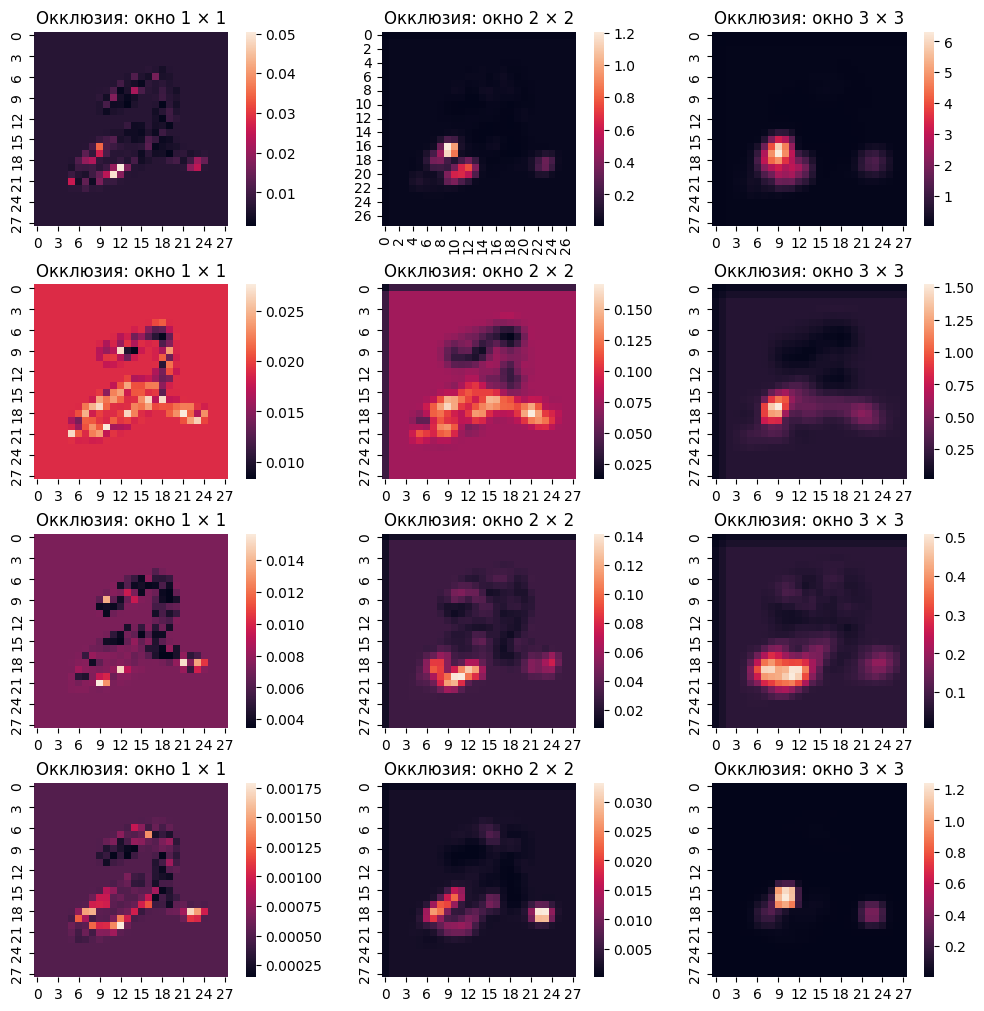

In [92]:
occlusion_image = np.array(to_image(X.iloc[5]))
fig, axes = plt.subplots(4, 3, figsize=(10, 10), constrained_layout=True)
models_occl = [models_with_different_p_balanced[0], models_with_different_p[1], models_with_different_p_sigmoid[0], models_with_different_p_clean[0]]
for i, m in enumerate(models_occl):
    for ax, kernel_size in zip(axes[i], (1, 2, 3)):
        heatmap = occlusion(m, kernel_size, occlusion_image, 2)
        sns.heatmap(heatmap, ax=ax, square=True)
        ax.set_title(f'Окклюзия: окно {kernel_size} × {kernel_size}')
plt.show()


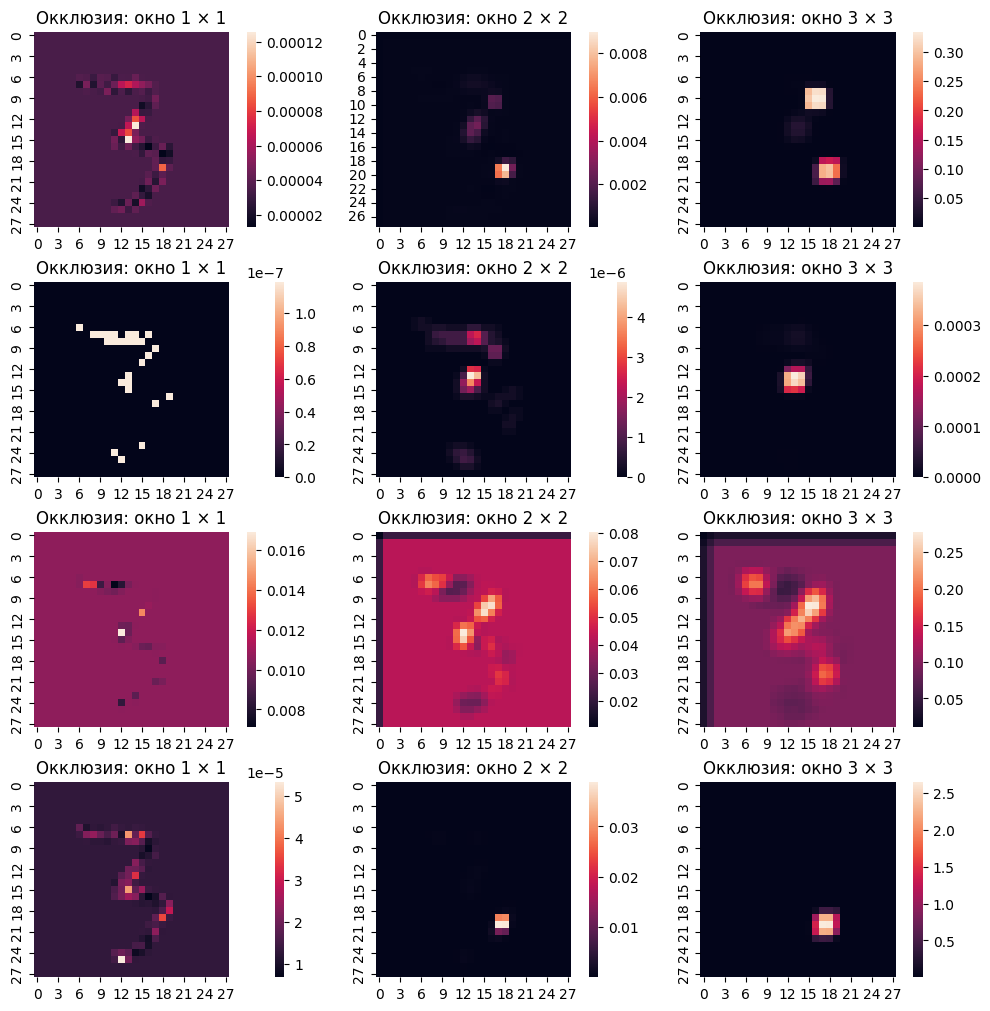

In [93]:
occlusion_image = np.array(to_image(X.iloc[44]))
fig, axes = plt.subplots(4, 3, figsize=(10, 10), constrained_layout=True)
models_occl = [models_with_different_p_balanced[0], models_with_different_p[1], models_with_different_p_sigmoid[0], models_with_different_p_clean[0]]
for i, m in enumerate(models_occl):
    for ax, kernel_size in zip(axes[i], (1, 2, 3)):
        heatmap = occlusion(m, kernel_size, occlusion_image, 3)
        sns.heatmap(heatmap, ax=ax, square=True)
        ax.set_title(f'Окклюзия: окно {kernel_size} × {kernel_size}')
plt.show()

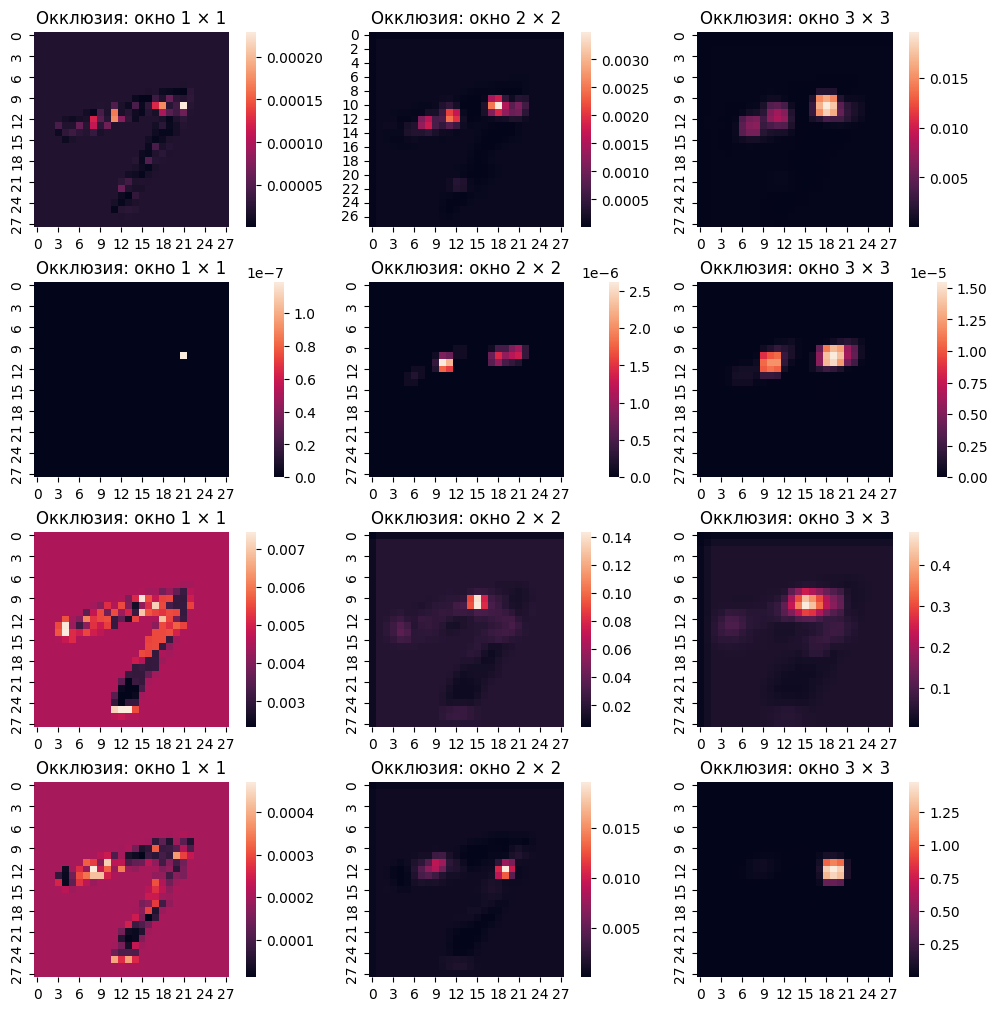

In [98]:
occlusion_image = np.array(to_image(X.iloc[101]))
fig, axes = plt.subplots(4, 3, figsize=(10, 10), constrained_layout=True)
models_occl = [models_with_different_p_balanced[0], models_with_different_p[1], models_with_different_p_sigmoid[0], models_with_different_p_clean[0]]
for i, m in enumerate(models_occl):
    for ax, kernel_size in zip(axes[i], (1, 2, 3)):
        heatmap = occlusion(m, kernel_size, occlusion_image, 7)
        sns.heatmap(heatmap, ax=ax, square=True)
        ax.set_title(f'Окклюзия: окно {kernel_size} × {kernel_size}')
plt.show()

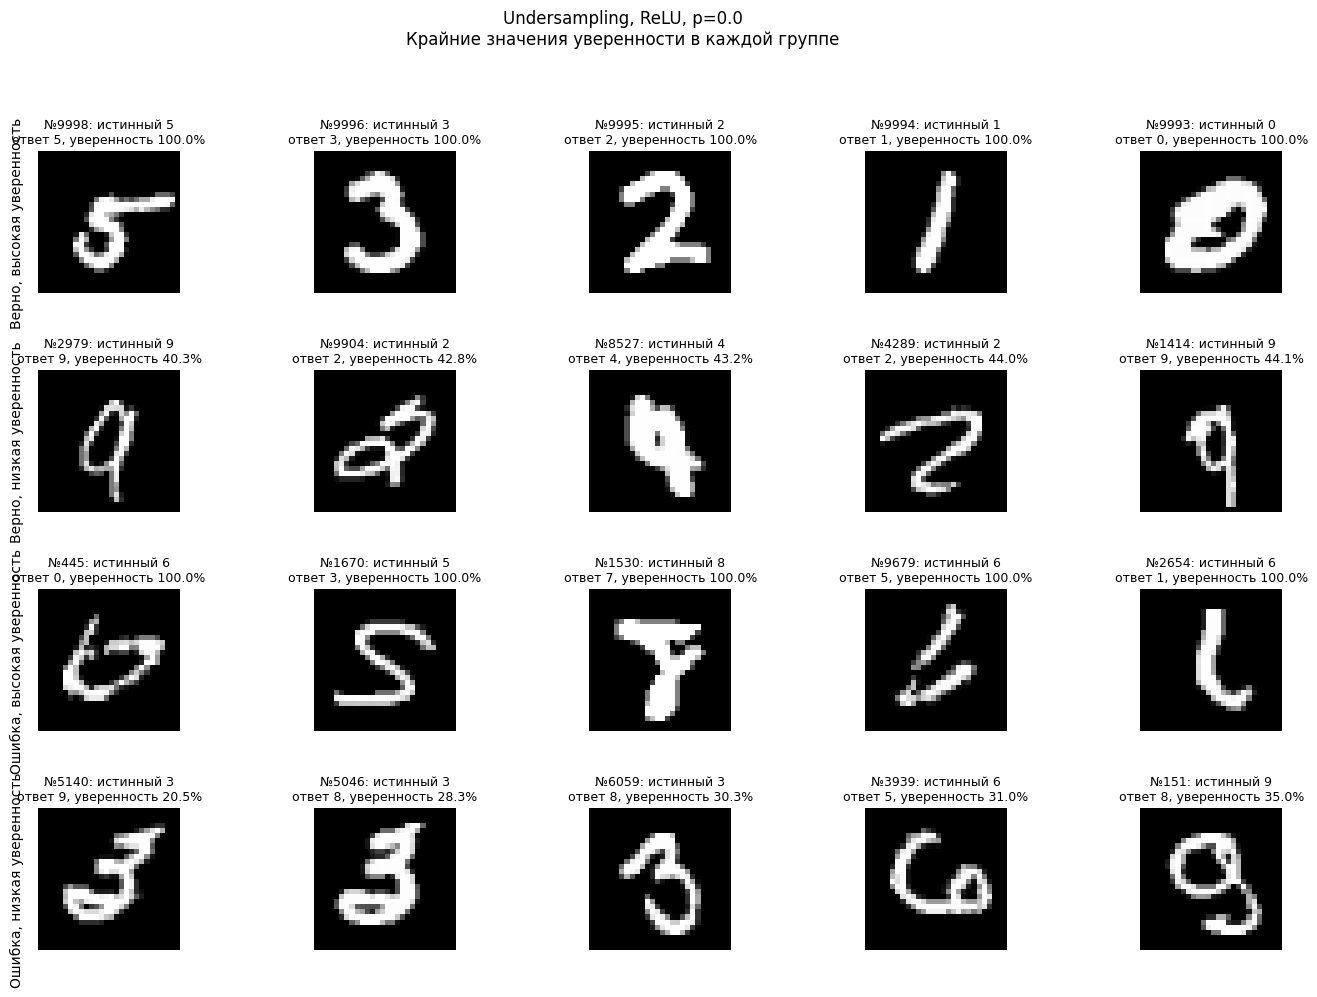

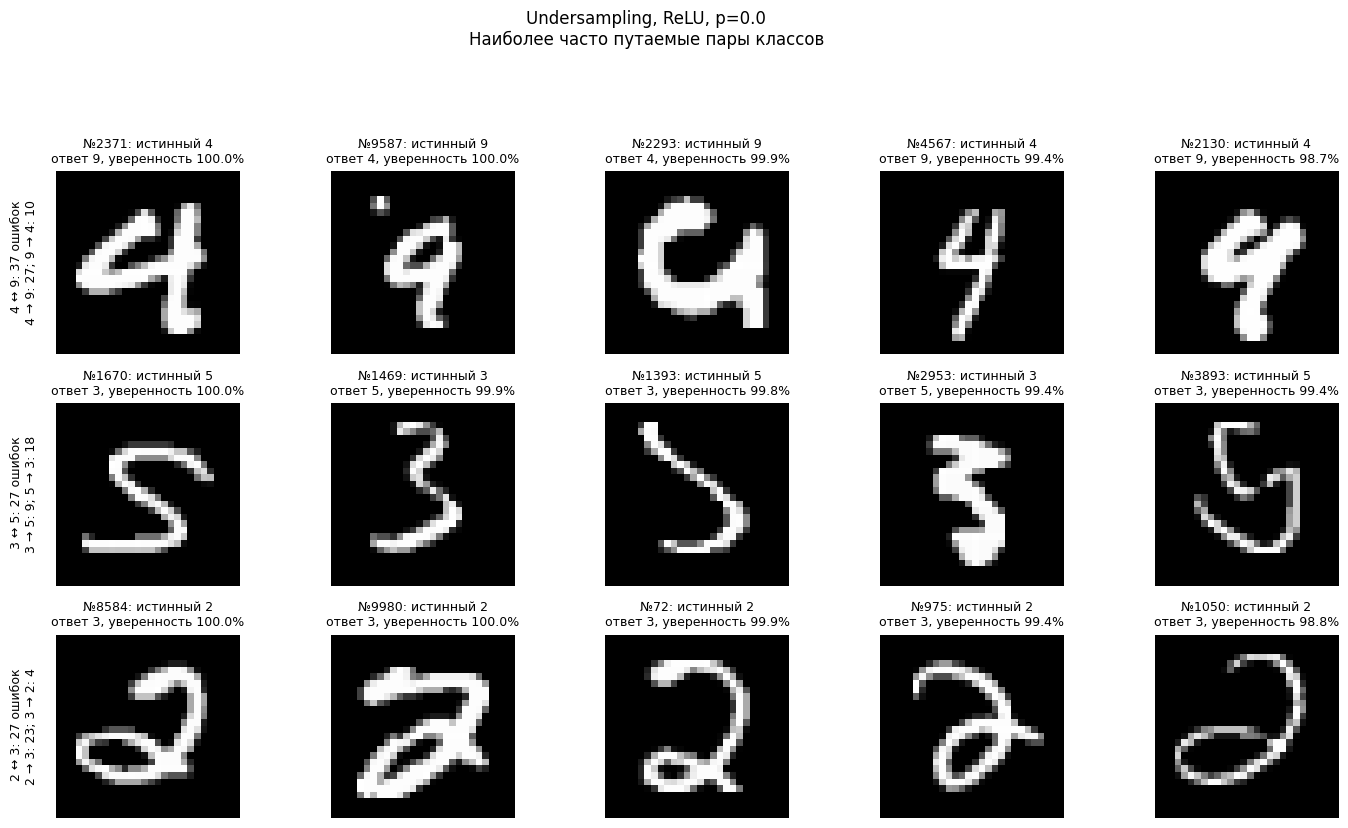

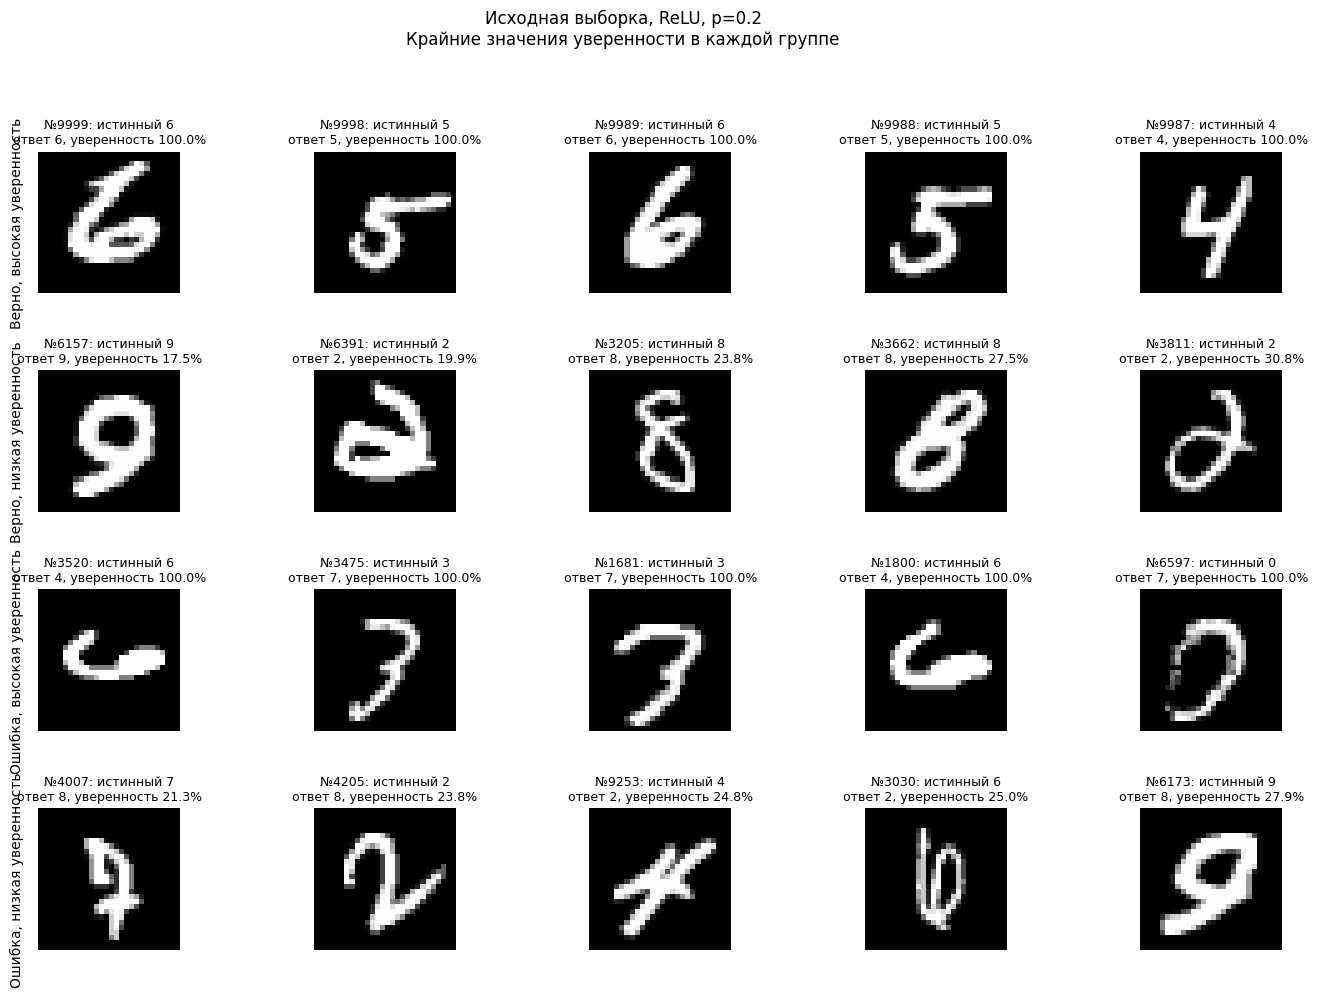

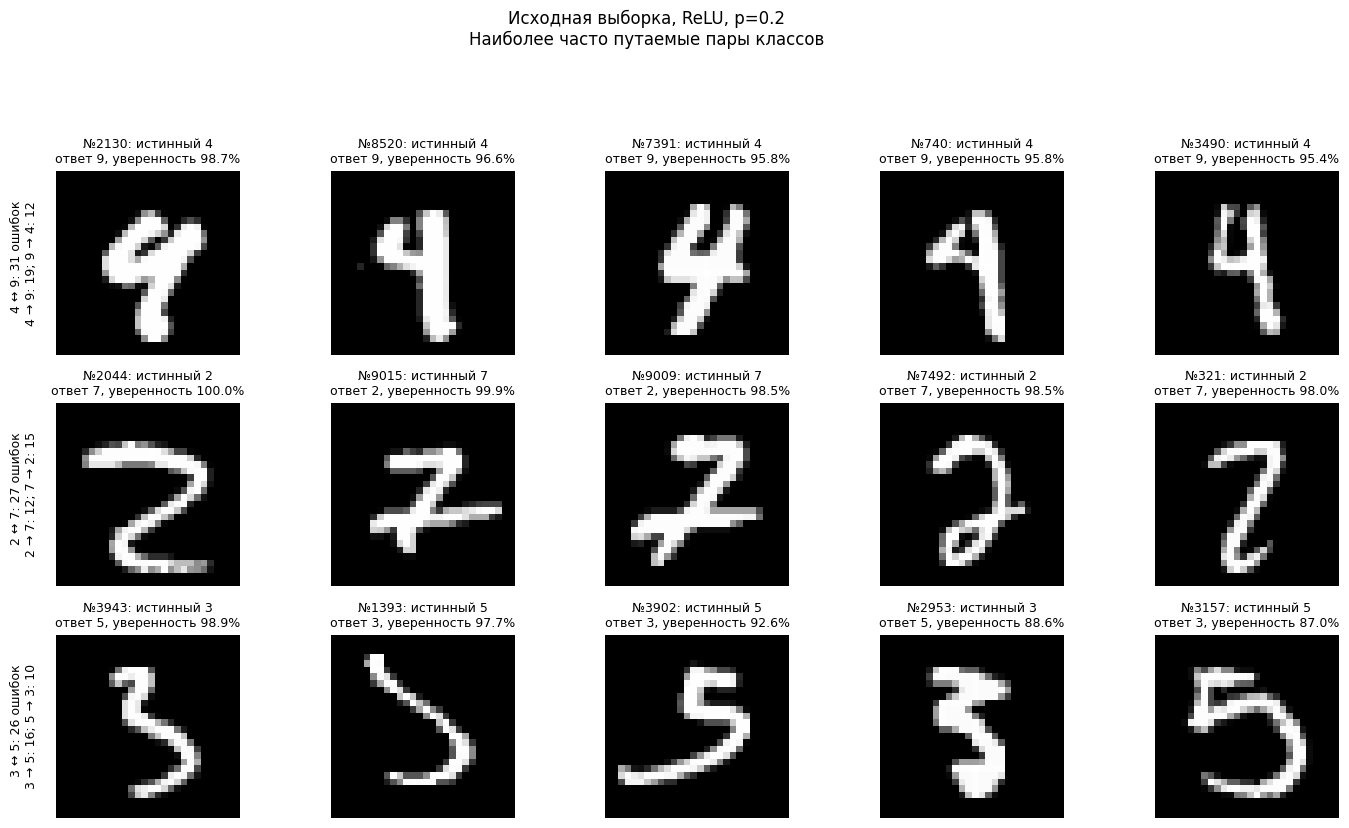

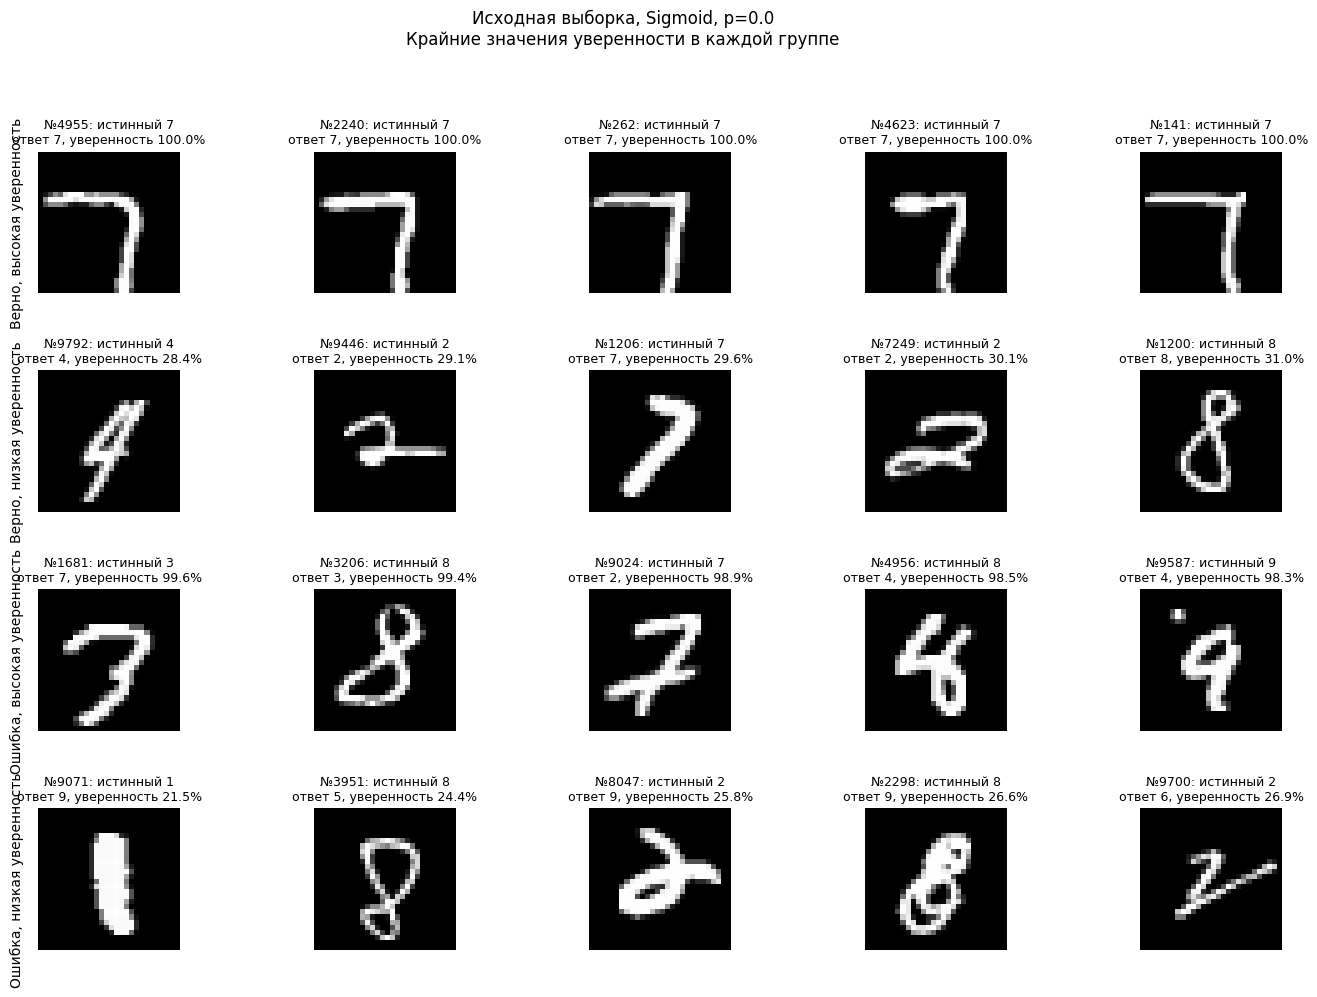

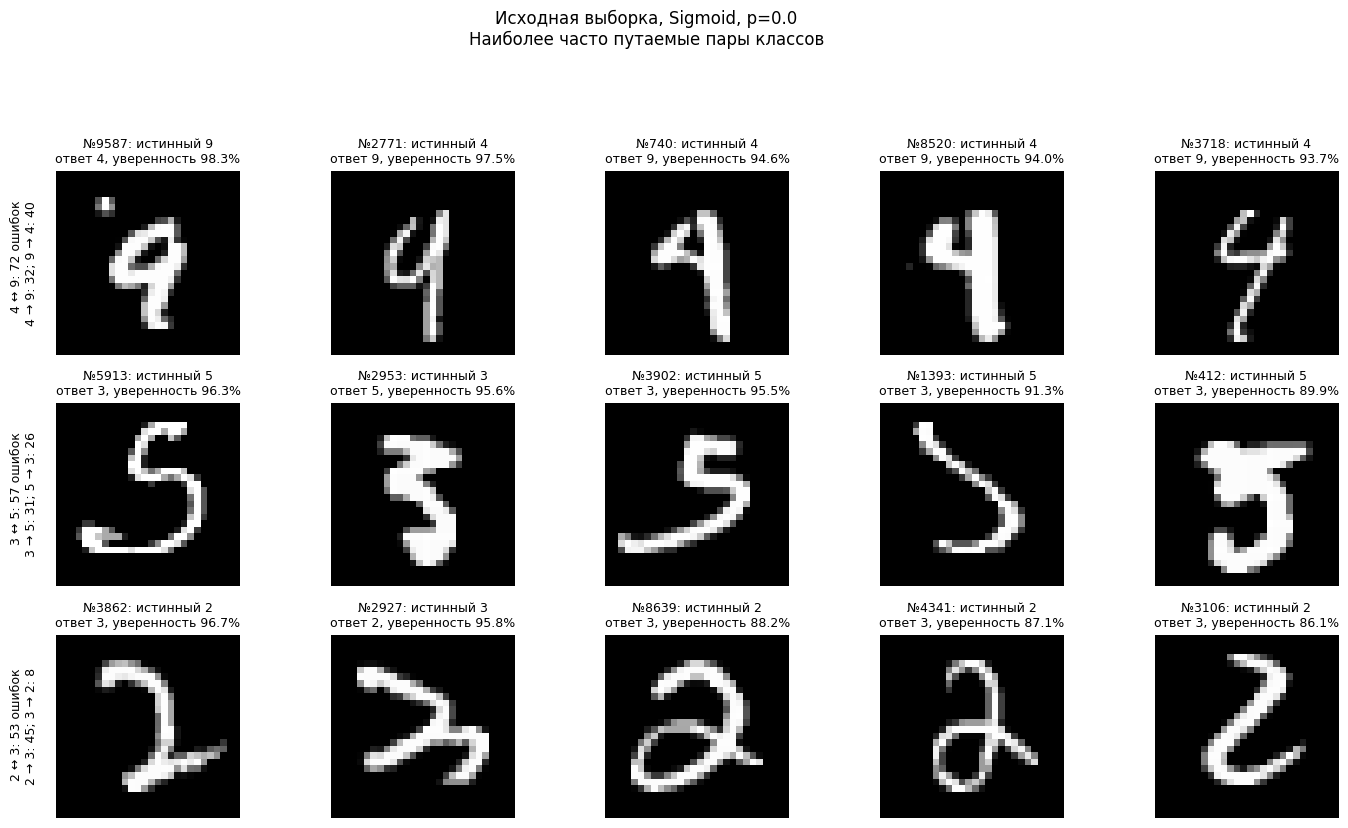

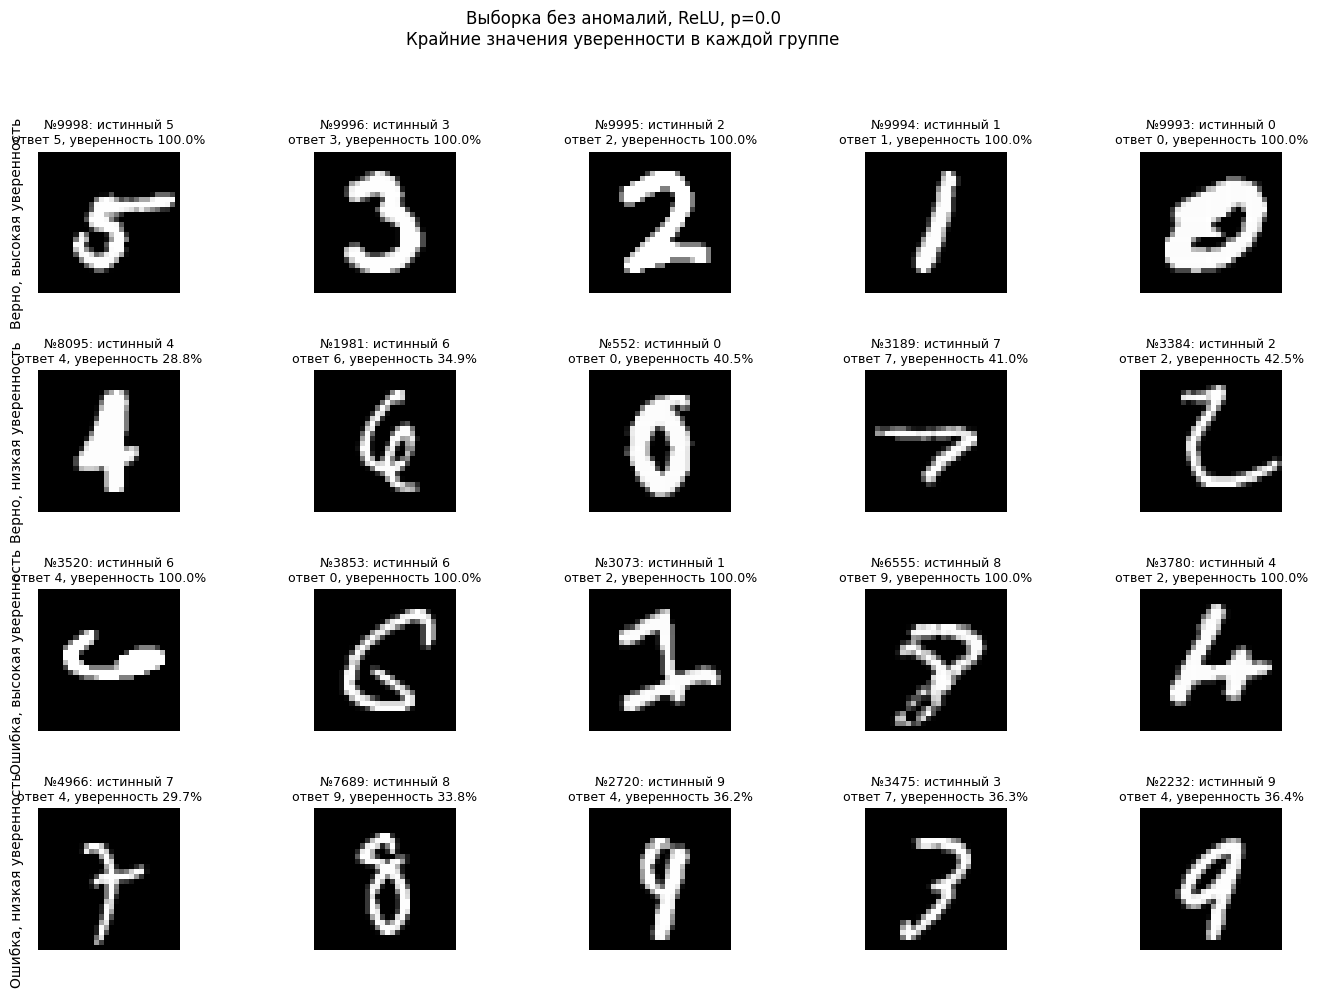

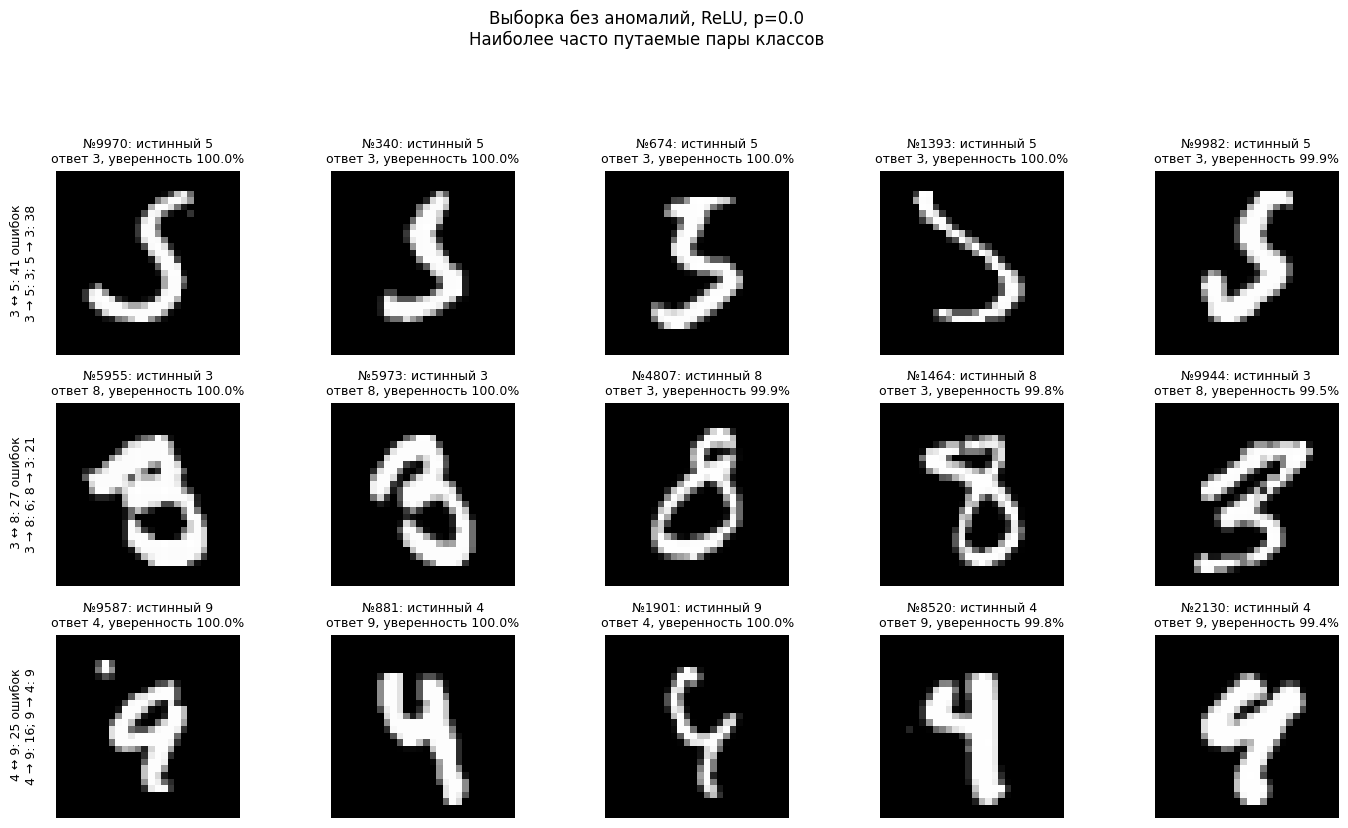

Различаются ответы хотя бы двух моделей: 1007 / 10000
Все три ответа различаются: 95


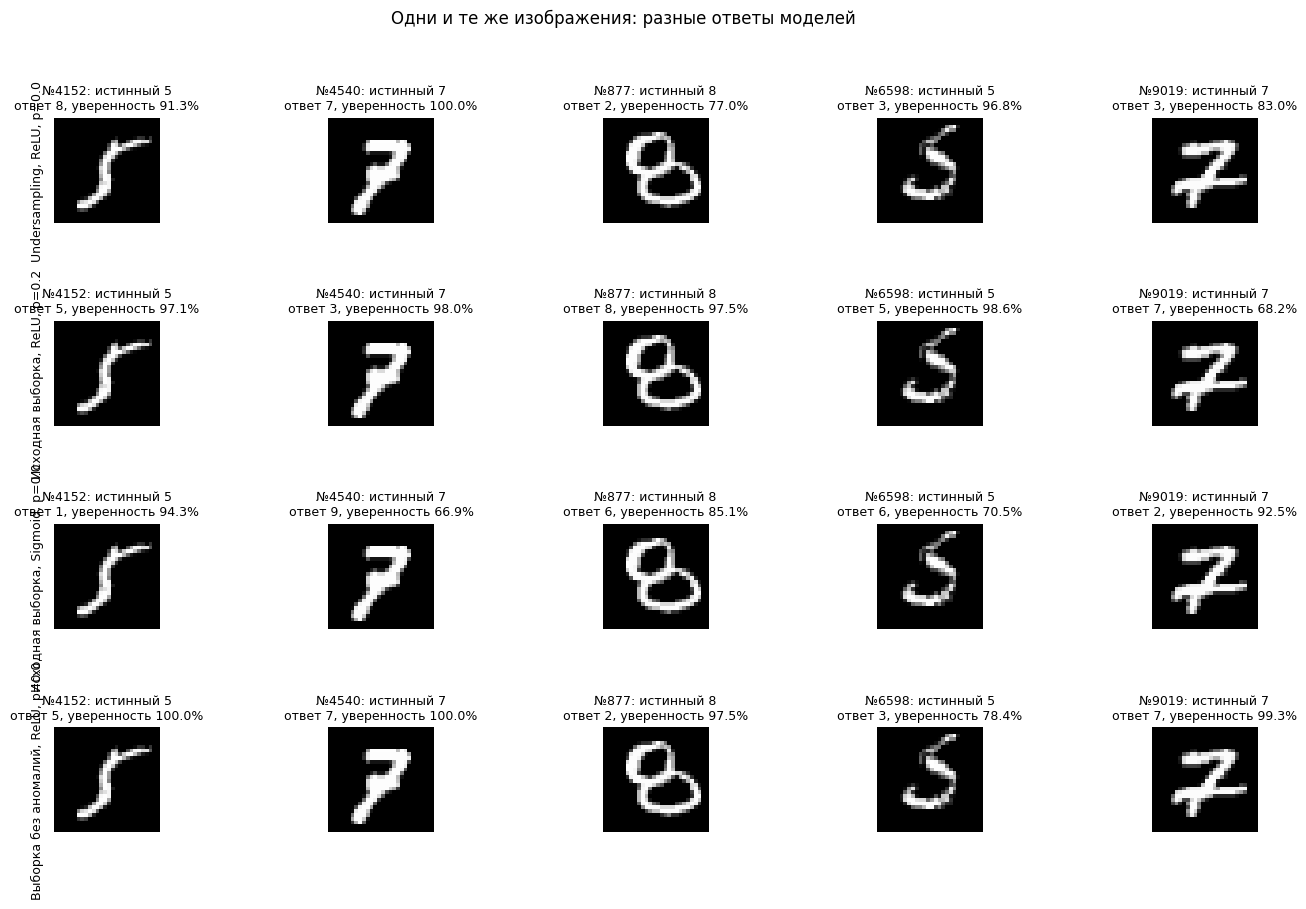

In [99]:
EXAMPLES_PER_GROUP = 5
TOP_CONFUSED_PAIRS = 3

comparison_models = {
    'Undersampling, ReLU, p=0.0': models_with_different_p_balanced[0],
    'Исходная выборка, ReLU, p=0.2': models_with_different_p[1],
    'Исходная выборка, Sigmoid, p=0.0': models_with_different_p_sigmoid[0],
    'Выборка без аномалий, ReLU, p=0.0': models_with_different_p_clean[0],
}
comparison_images = np.asarray(X_test, dtype=np.float32)
comparison_targets = np.asarray(y_test, dtype=np.int64)
comparison_results = {}


def collect_predictions(model, images, batch_size=256):
    parameter = next(model.parameters())
    was_training = model.training
    model.eval()
    probabilities = []
    try:
        with torch.no_grad():
            for start in range(0, len(images), batch_size):
                batch = torch.as_tensor(
                    images[start:start + batch_size],
                    dtype=parameter.dtype, device=parameter.device,
                )
                probabilities.append(torch.softmax(model(batch), dim=1).cpu())
    finally:
        model.train(was_training)
    probabilities = torch.cat(probabilities).numpy()
    predictions = probabilities.argmax(axis=1)
    confidence = probabilities.max(axis=1)
    return {'predictions': predictions, 'confidence': confidence}


def draw_prediction_example(ax, index, result):
    ax.imshow(comparison_images[index].reshape(28, 28), cmap='gray', vmin=0, vmax=255)
    ax.set_title(
        f'№{index}: истинный {comparison_targets[index]}\n'
        f'ответ {result["predictions"][index]}, '
        f'уверенность {result["confidence"][index]:.1%}', fontsize=9,
    )
    ax.axis('off')


for model_name, comparison_model in comparison_models.items():
    result = collect_predictions(comparison_model, comparison_images)
    comparison_results[model_name] = result
    correct = result['predictions'] == comparison_targets
    groups = [
        ('Верно, высокая уверенность', correct, True),
        ('Верно, низкая уверенность', correct, False),
        ('Ошибка, высокая уверенность', ~correct, True),
        ('Ошибка, низкая уверенность', ~correct, False),
    ]
    fig, axes = plt.subplots(4, EXAMPLES_PER_GROUP, figsize=(15, 10), squeeze=False)
    fig.suptitle(model_name + '\nКрайние значения уверенности в каждой группе')
    for row, (title, mask, descending) in enumerate(groups):
        indices = np.flatnonzero(mask)
        order = np.argsort(result['confidence'][indices], kind='stable')
        if descending:
            order = order[::-1]
        selected = indices[order[:EXAMPLES_PER_GROUP]]
        for column, ax in enumerate(axes[row]):
            if column < len(selected):
                draw_prediction_example(ax, selected[column], result)
            else:
                ax.axis('off')
                ax.text(0.5, 0.5, 'Нет примеров', ha='center', va='center')
        axes[row, 0].text(-0.1, 0.5, title, transform=axes[row, 0].transAxes,
                          rotation=90, ha='right', va='center', fontsize=10)
    fig.tight_layout(rect=(0.04, 0, 1, 0.94))
    plt.show()

    class_labels = np.arange(10)
    cm = confusion_matrix(comparison_targets, result['predictions'], labels=class_labels)
    pairs = [(int(cm[a, b] + cm[b, a]), a, b)
             for a in class_labels for b in class_labels if a < b]
    pairs = sorted((pair for pair in pairs if pair[0] > 0), reverse=True)[:TOP_CONFUSED_PAIRS]
    result['top_confused_pairs'] = pairs
    if not pairs:
        print(f'{model_name}: ошибок нет, путаемых пар нет.')
        continue
    fig, axes = plt.subplots(len(pairs), EXAMPLES_PER_GROUP,
                             figsize=(15, 2.8 * len(pairs)), squeeze=False)
    fig.suptitle(model_name + '\nНаиболее часто путаемые пары классов')
    for row, (count, a, b) in enumerate(pairs):
        mask = (((comparison_targets == a) & (result['predictions'] == b)) |
                ((comparison_targets == b) & (result['predictions'] == a)))
        indices = np.flatnonzero(mask)
        selected = indices[np.argsort(-result['confidence'][indices])[:EXAMPLES_PER_GROUP]]
        for column, ax in enumerate(axes[row]):
            if column < len(selected):
                draw_prediction_example(ax, selected[column], result)
            else:
                ax.axis('off')
        axes[row, 0].text(
            -0.1, 0.5, f'{a} ↔ {b}: {count} ошибок\n{a} → {b}: {cm[a, b]}; {b} → {a}: {cm[b, a]}',
            transform=axes[row, 0].transAxes, rotation=90, ha='right', va='center', fontsize=9,
        )
    fig.tight_layout(rect=(0.04, 0, 1, 0.91))
    plt.show()

model_names = list(comparison_results)
all_predictions = np.column_stack([comparison_results[name]['predictions'] for name in model_names])
all_confidence = np.column_stack([comparison_results[name]['confidence'] for name in model_names])
disagreement_indices = np.flatnonzero(np.any(all_predictions != all_predictions[:, :1], axis=1))
print(f'Различаются ответы хотя бы двух моделей: {len(disagreement_indices)} / {len(comparison_targets)}')

all_three_differ = ((all_predictions[:, 0] != all_predictions[:, 1]) &
                    (all_predictions[:, 0] != all_predictions[:, 2]) &
                    (all_predictions[:, 1] != all_predictions[:, 2]))
print(f'Все три ответа различаются: {all_three_differ.sum()}')
order = np.lexsort((-all_confidence[disagreement_indices].mean(axis=1),
                    -all_three_differ[disagreement_indices].astype(int)))
selected = disagreement_indices[order[:EXAMPLES_PER_GROUP]]
if len(selected):
    fig, axes = plt.subplots(4, len(selected), figsize=(3 * len(selected), 9), squeeze=False)
    fig.suptitle('Одни и те же изображения: разные ответы моделей')
    for row, model_name in enumerate(model_names):
        for column, index in enumerate(selected):
            draw_prediction_example(axes[row, column], index, comparison_results[model_name])
        axes[row, 0].text(-0.1, 0.5, model_name, transform=axes[row, 0].transAxes,
                          rotation=90, ha='right', va='center', fontsize=9)
    fig.tight_layout(rect=(0.04, 0, 1, 0.95))
    plt.show()
else:
    print('Предсказания всех трёх моделей совпадают на всей тестовой выборке.')


Undersampling, ReLU, p=0.2: верно 55/90, accuracy=61.1%
Исходная выборка, ReLU, p=0.2: верно 51/90, accuracy=56.7%
Исходная выборка, Sigmoid, p=0.0: верно 17/90, accuracy=18.9%
Выборка без аномалий, ReLU, p=0.0: верно 31/90, accuracy=34.4%


,Истинный класс,"Undersampling, ReLU, p=0.2: ответ","Undersampling, ReLU, p=0.2: уверенность","Undersampling, ReLU, p=0.2: верно","Исходная выборка, ReLU, p=0.2: ответ","Исходная выборка, ReLU, p=0.2: уверенность","Исходная выборка, ReLU, p=0.2: верно","Исходная выборка, Sigmoid, p=0.0: ответ","Исходная выборка, Sigmoid, p=0.0: уверенность","Исходная выборка, Sigmoid, p=0.0: верно","Выборка без аномалий, ReLU, p=0.0: ответ","Выборка без аномалий, ReLU, p=0.0: уверенность","Выборка без аномалий, ReLU, p=0.0: верно"
Индекс изображения,,,,,,,,,,,,,
212,7,7,0.999878,True,7,0.501304,True,1,0.363777,False,9,0.925064,False
224,1,7,0.901214,False,1,0.852203,True,9,0.496802,False,2,0.892753,False
902,9,0,0.997952,False,0,0.996874,False,0,0.943400,False,0,0.999042,False
1352,9,3,0.992249,False,3,0.965293,False,3,0.964836,False,3,0.999952,False
3717,6,6,0.996250,True,6,0.992964,True,6,0.903765,True,6,0.999987,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59653,0,0,0.917270,True,9,0.560692,False,9,0.537347,False,4,0.965198,False
59701,5,6,0.992766,False,6,0.999359,False,6,0.990826,False,6,0.999717,False
59726,5,2,0.894342,False,5,0.927620,True,6,0.305758,False,2,0.873198,False


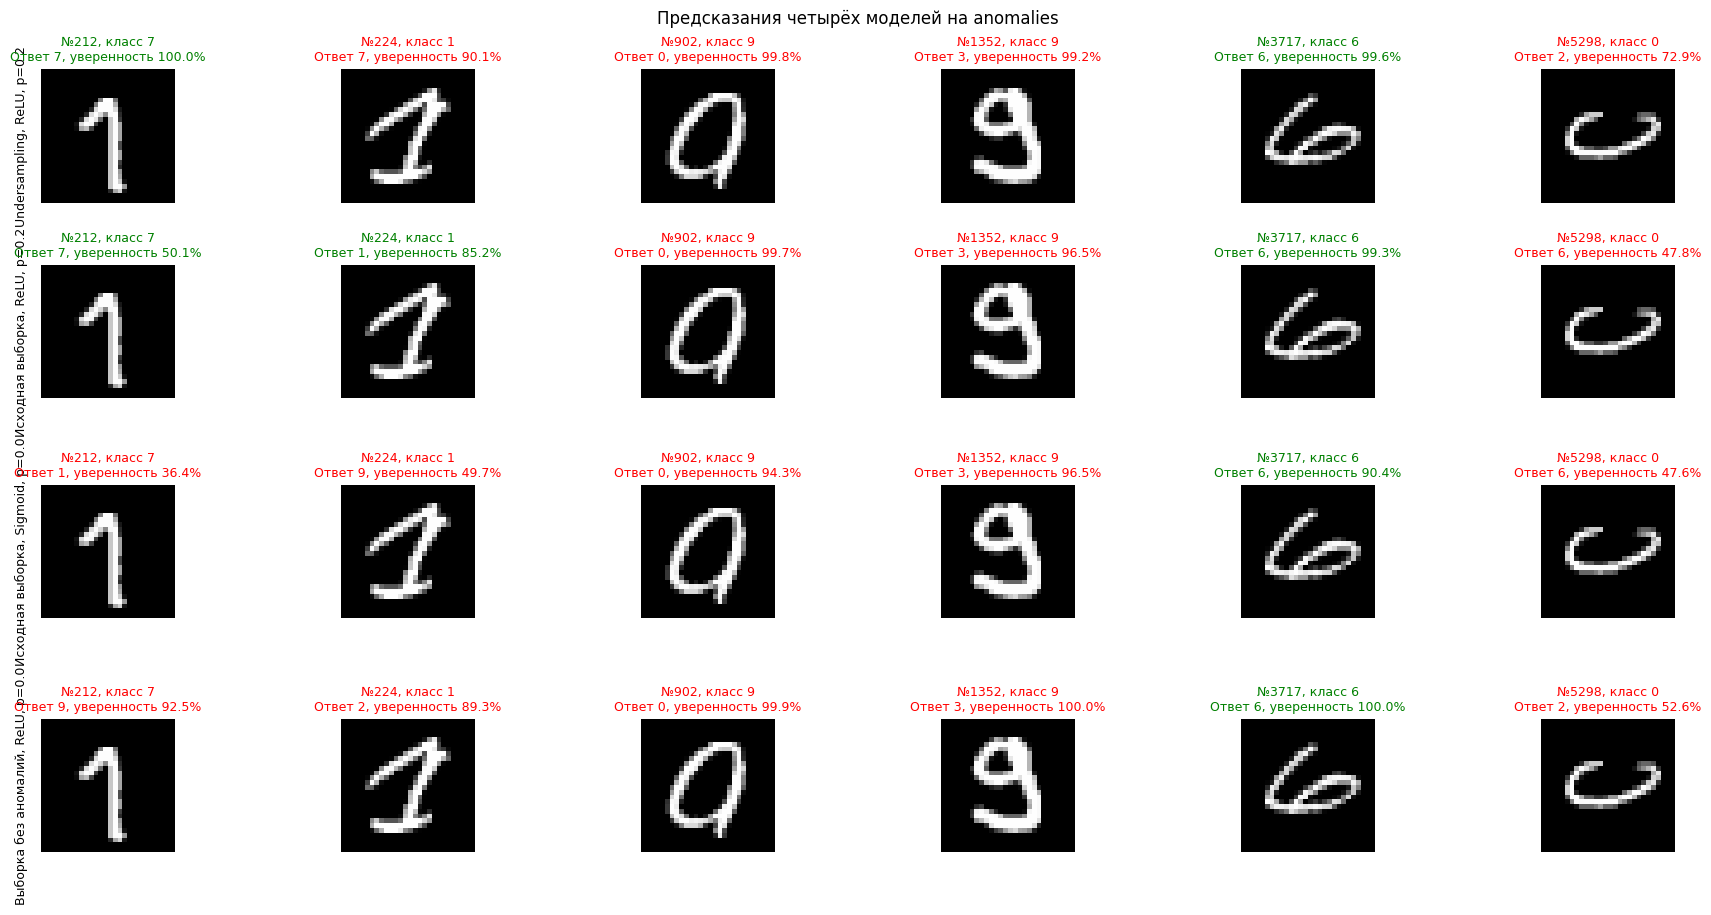

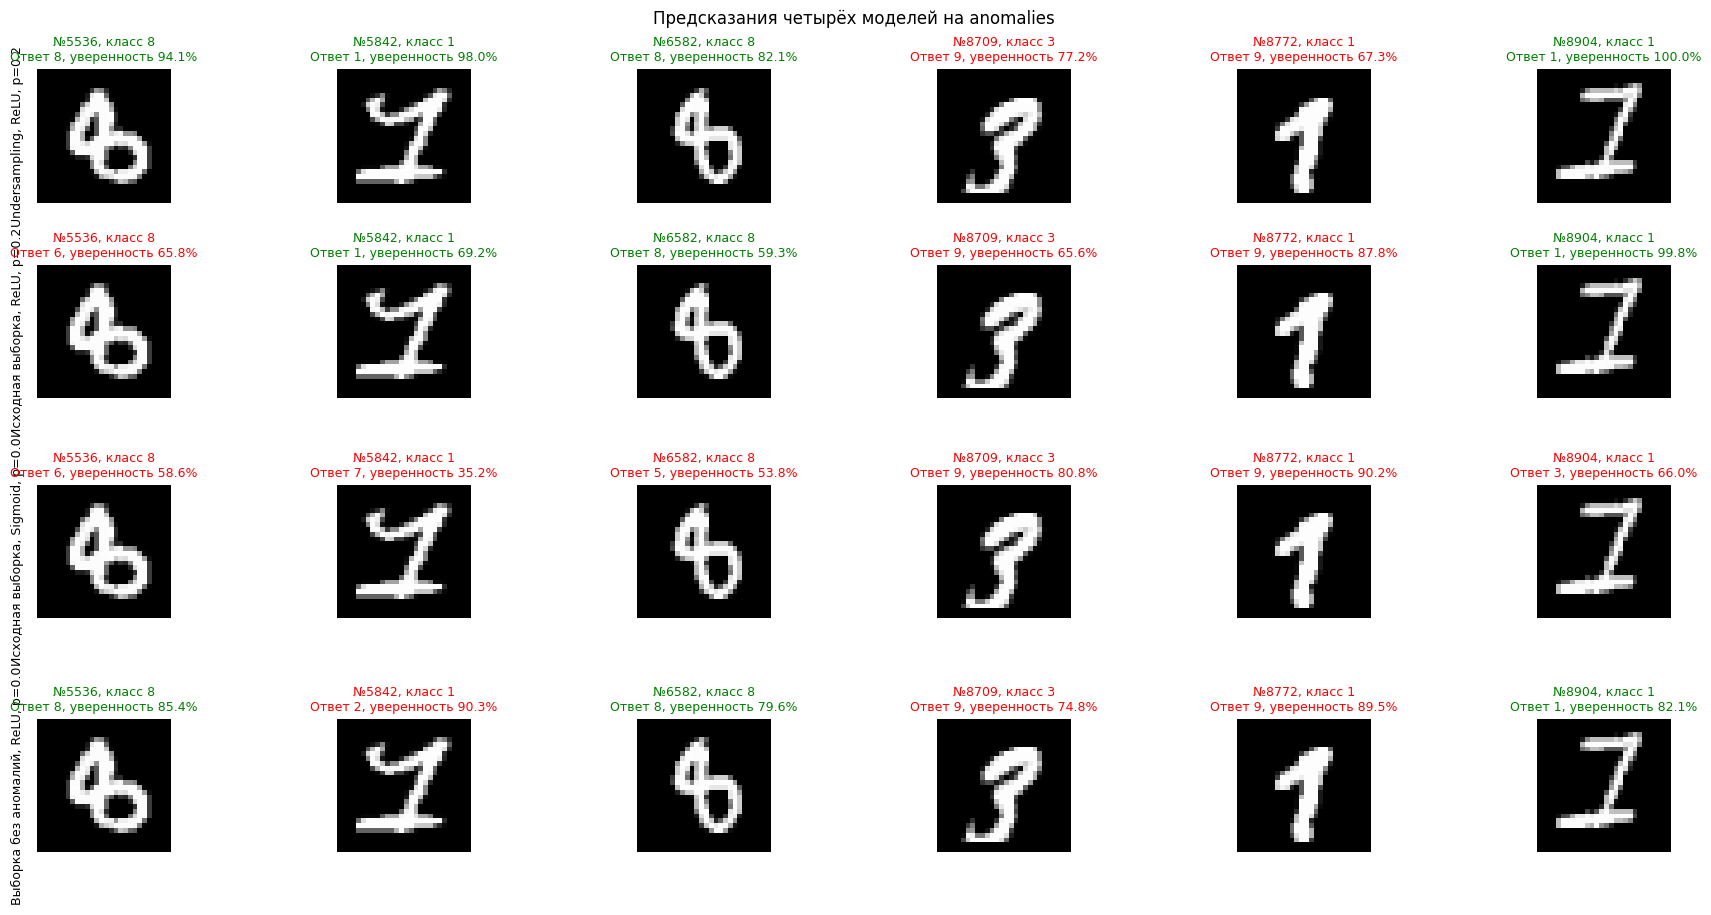

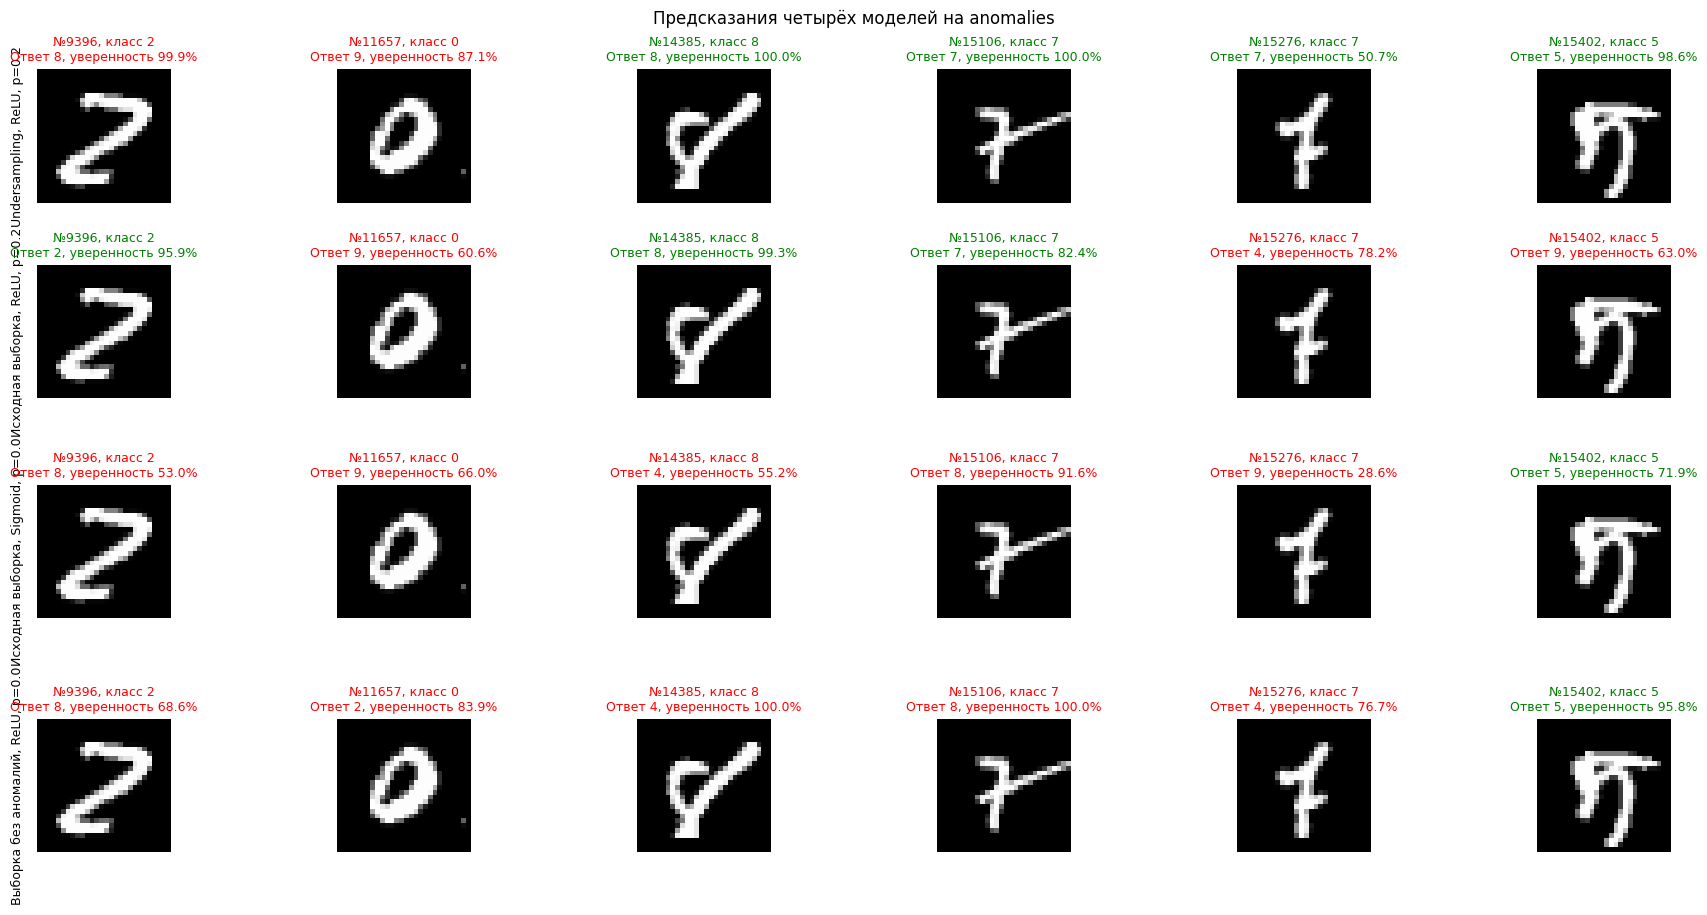

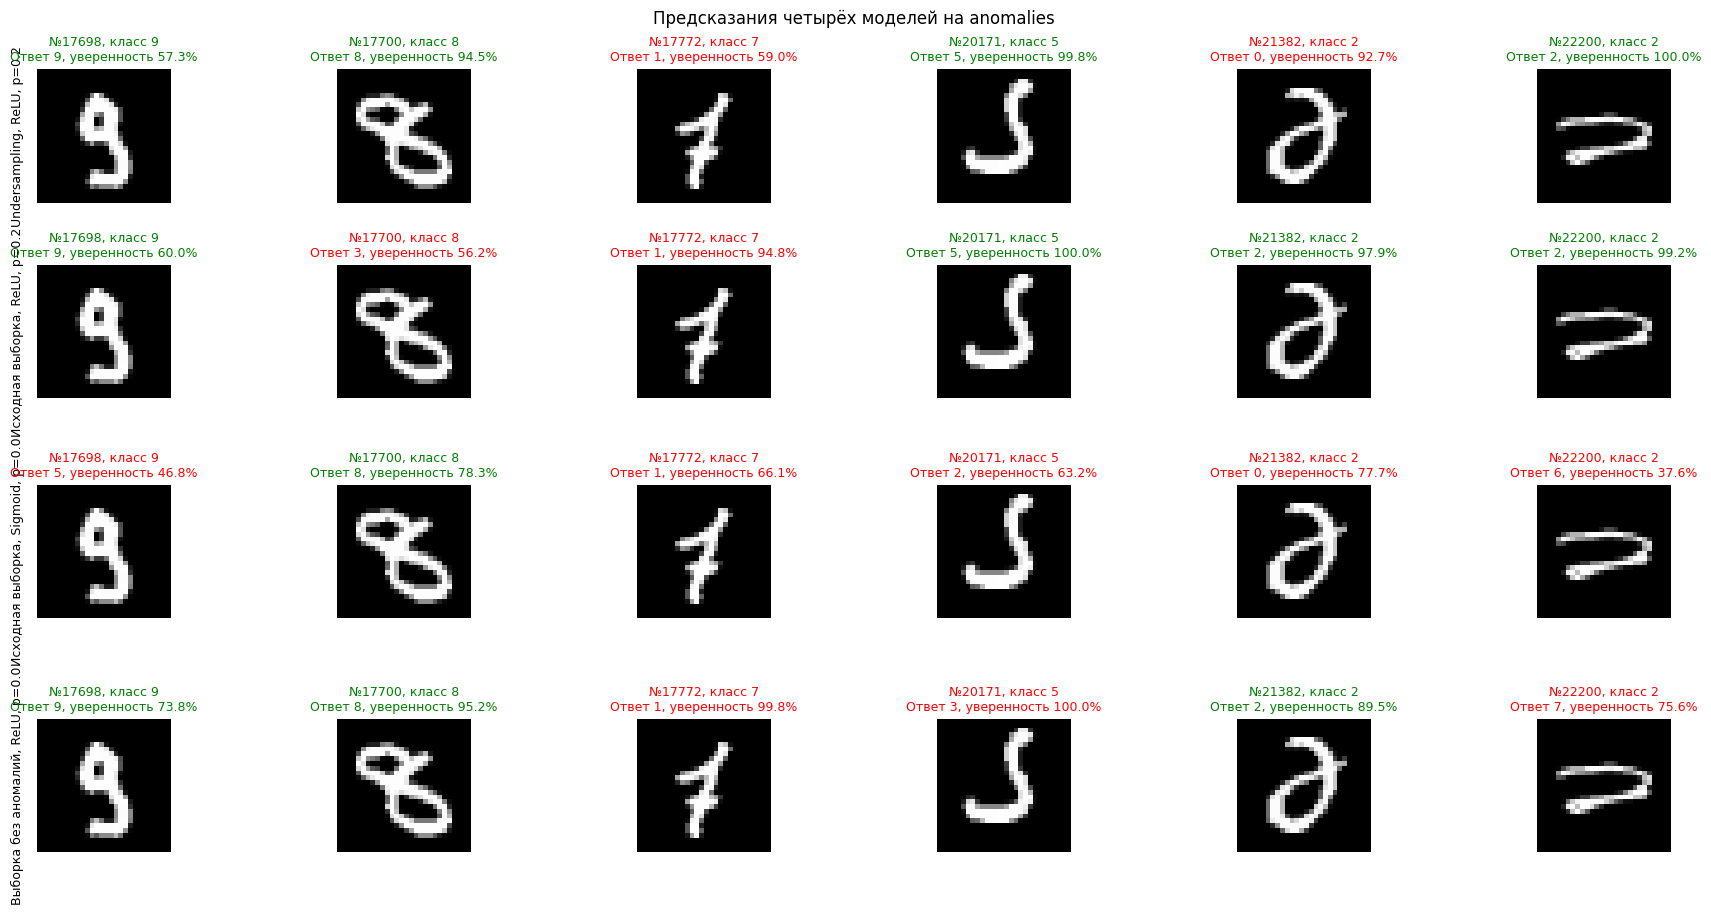

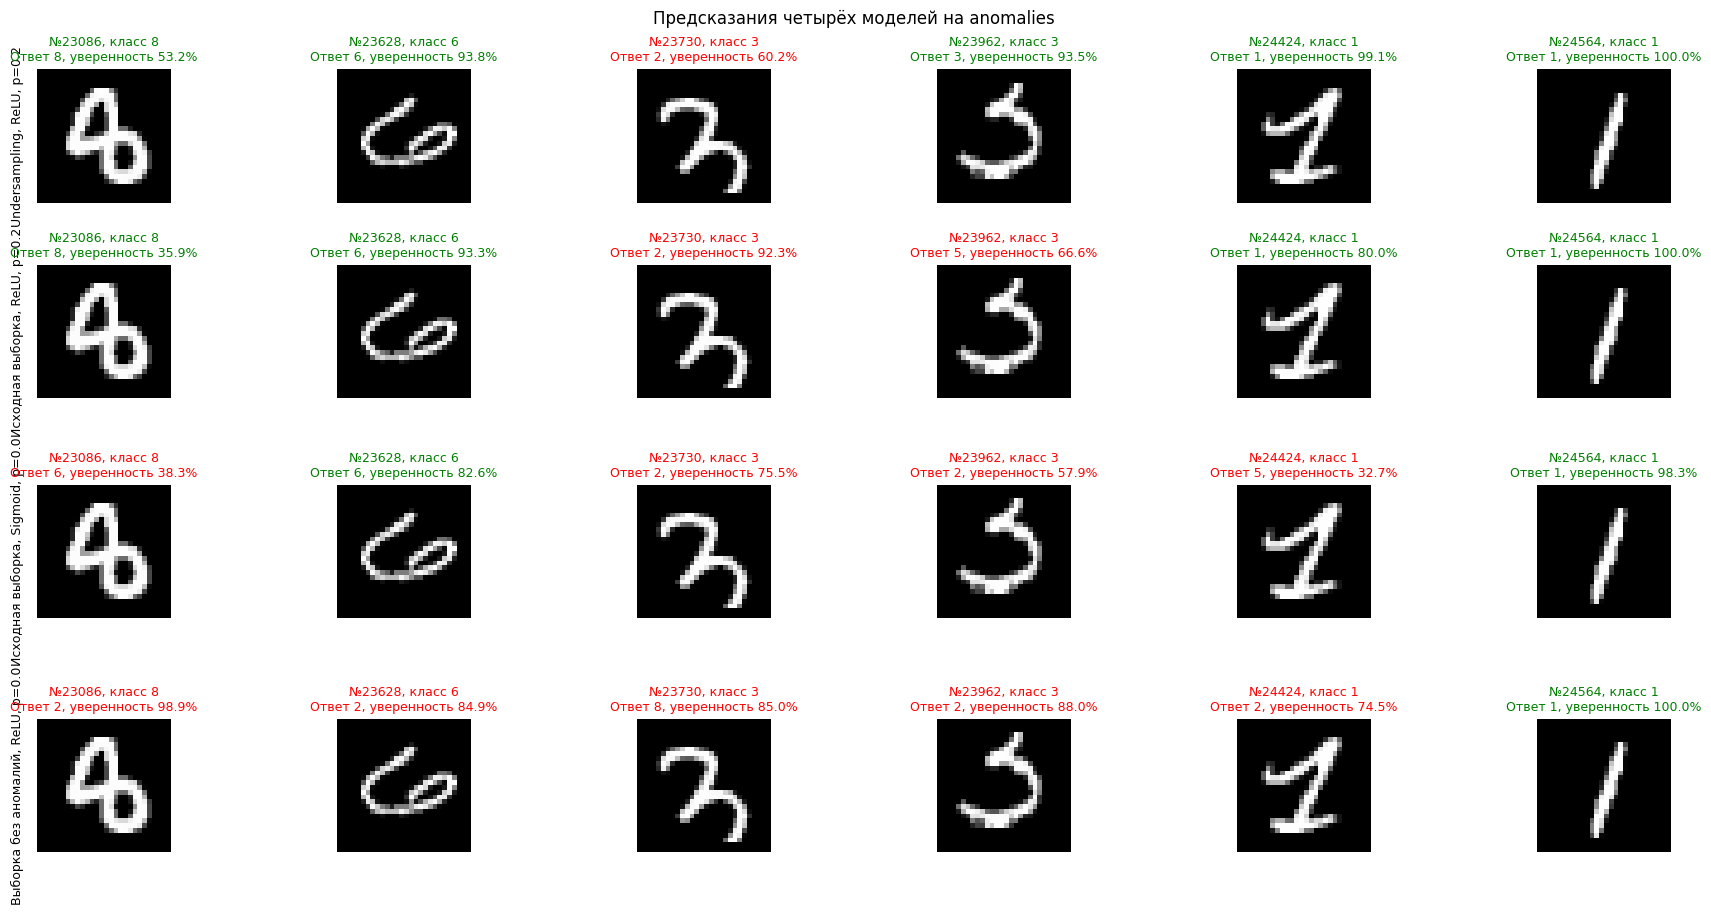

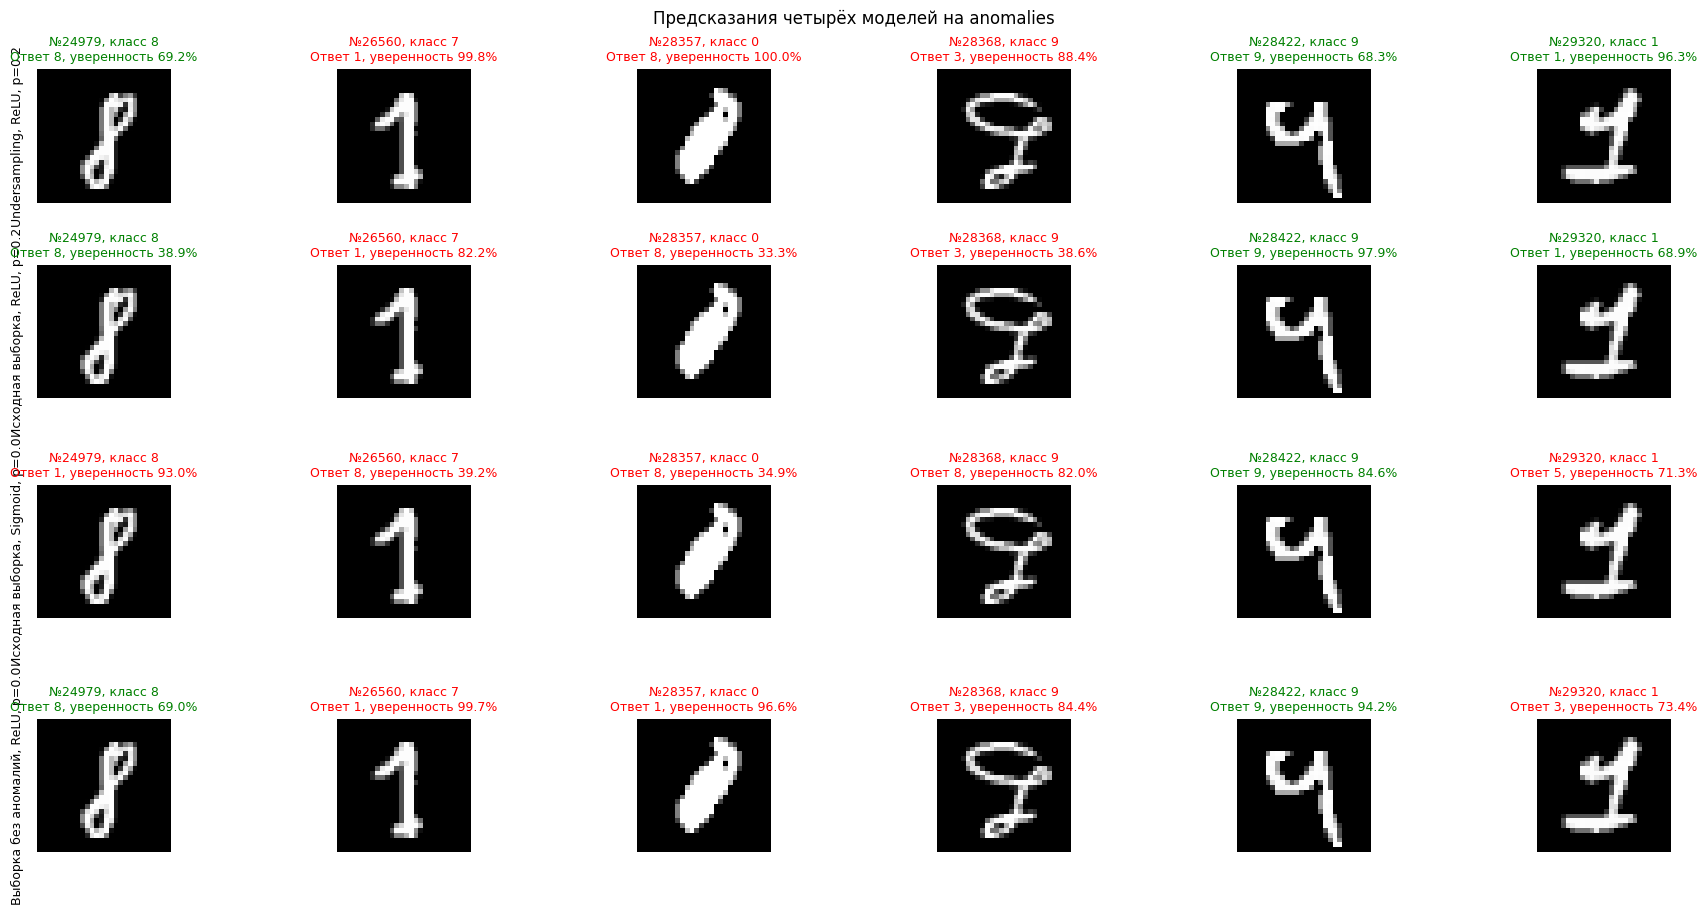

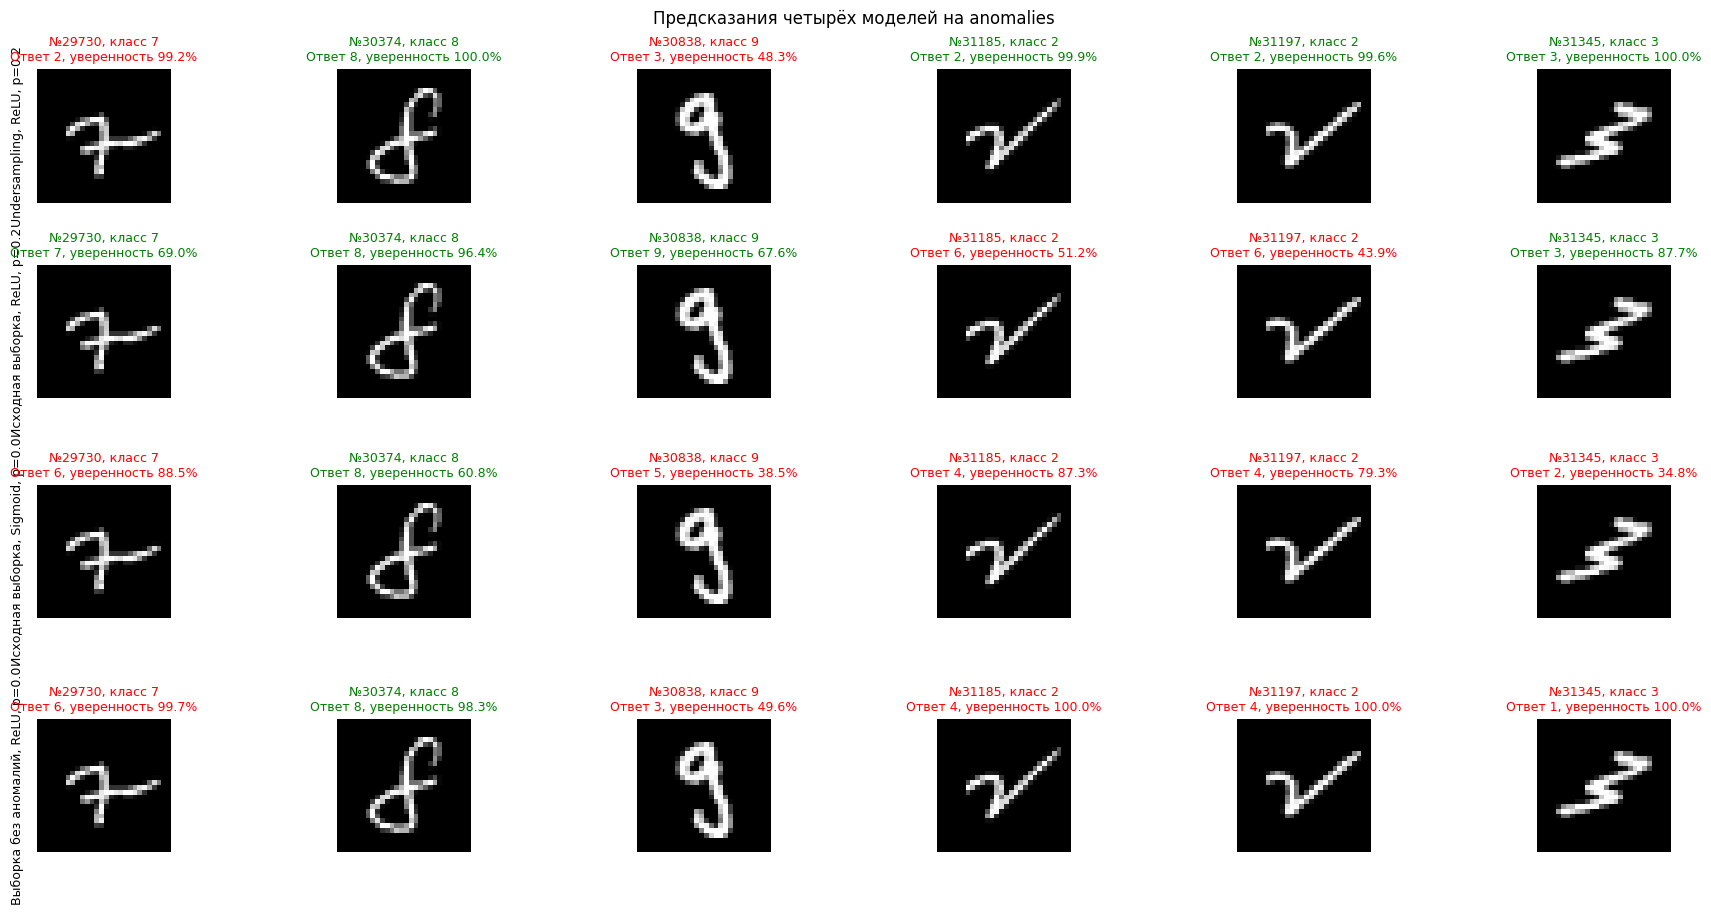

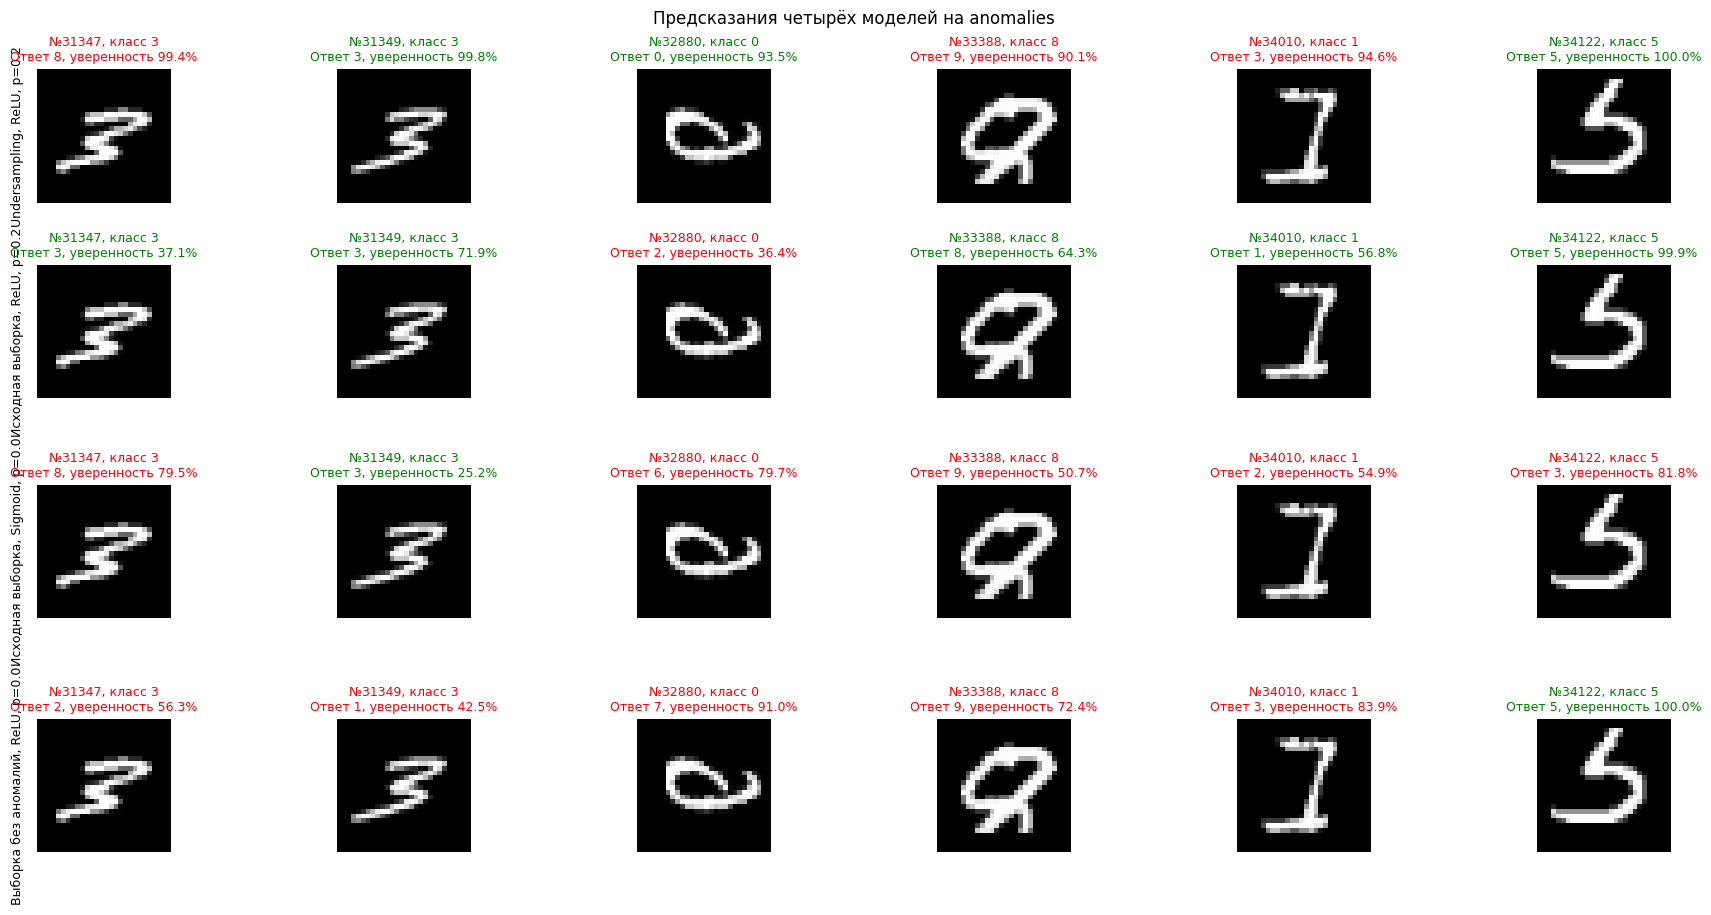

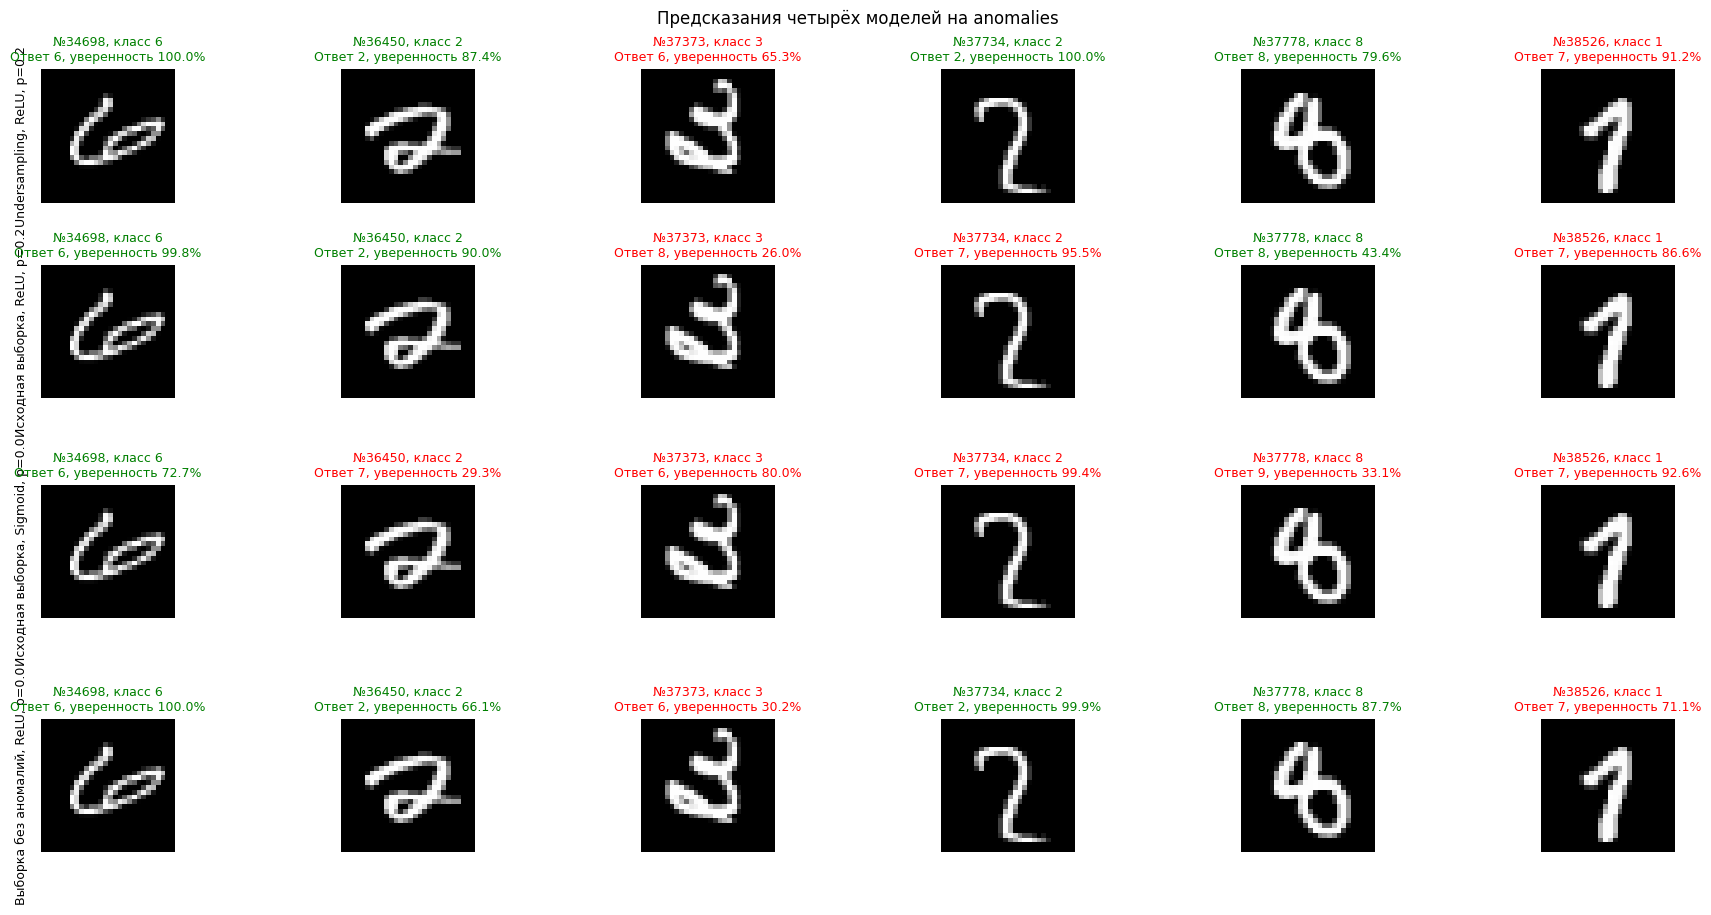

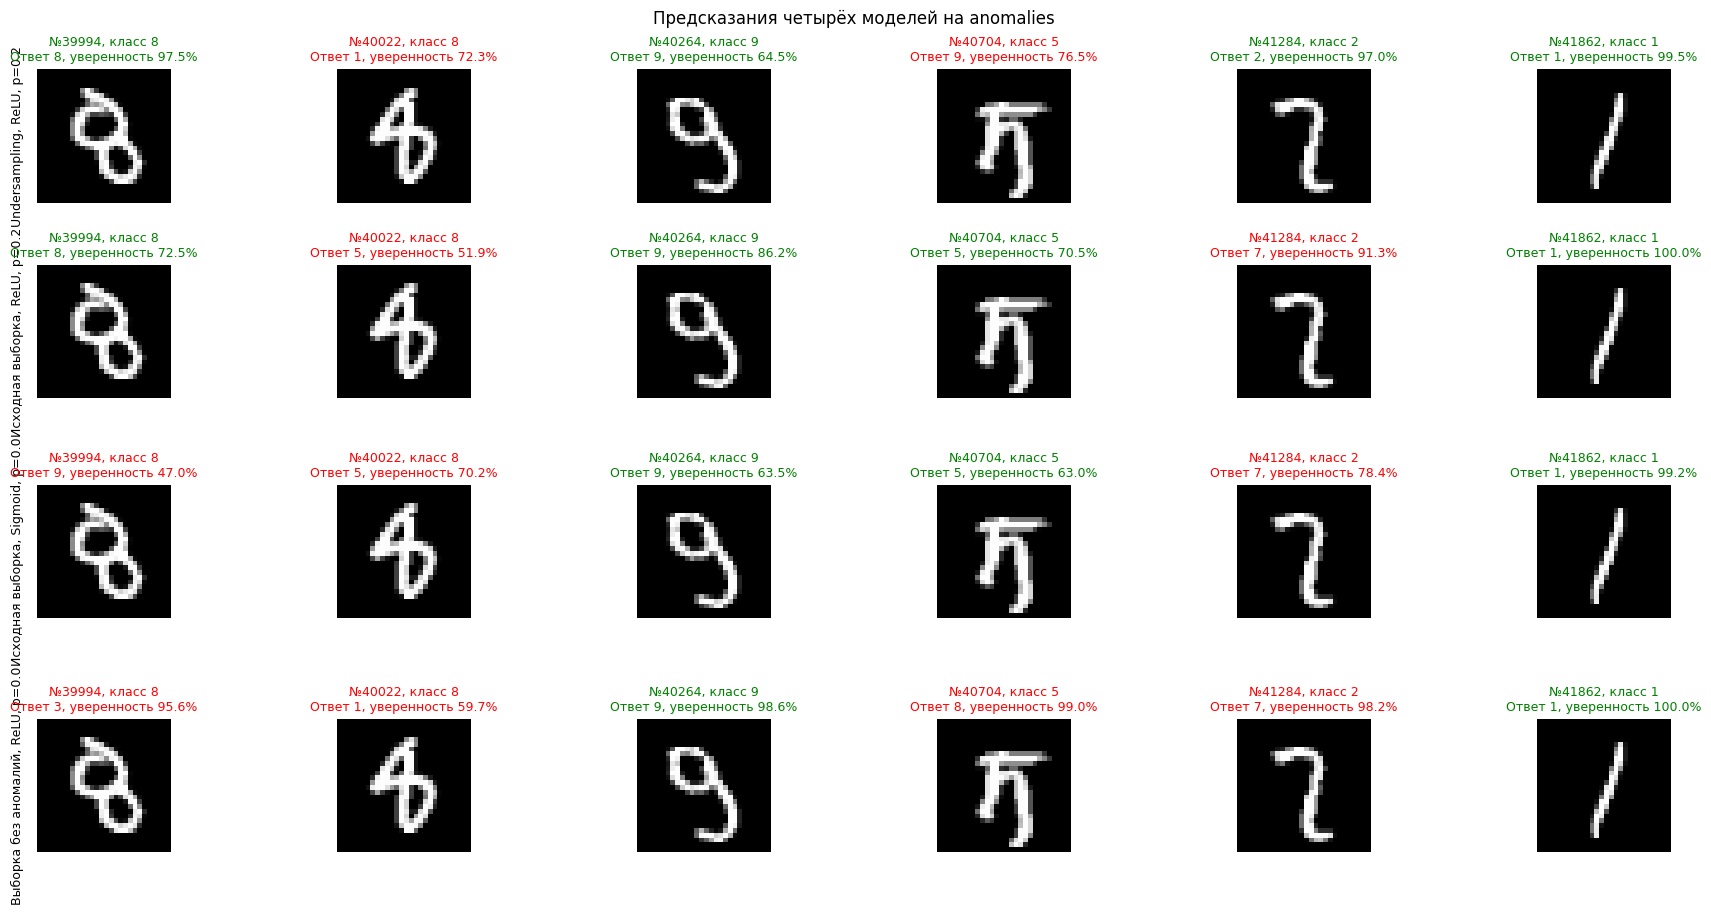

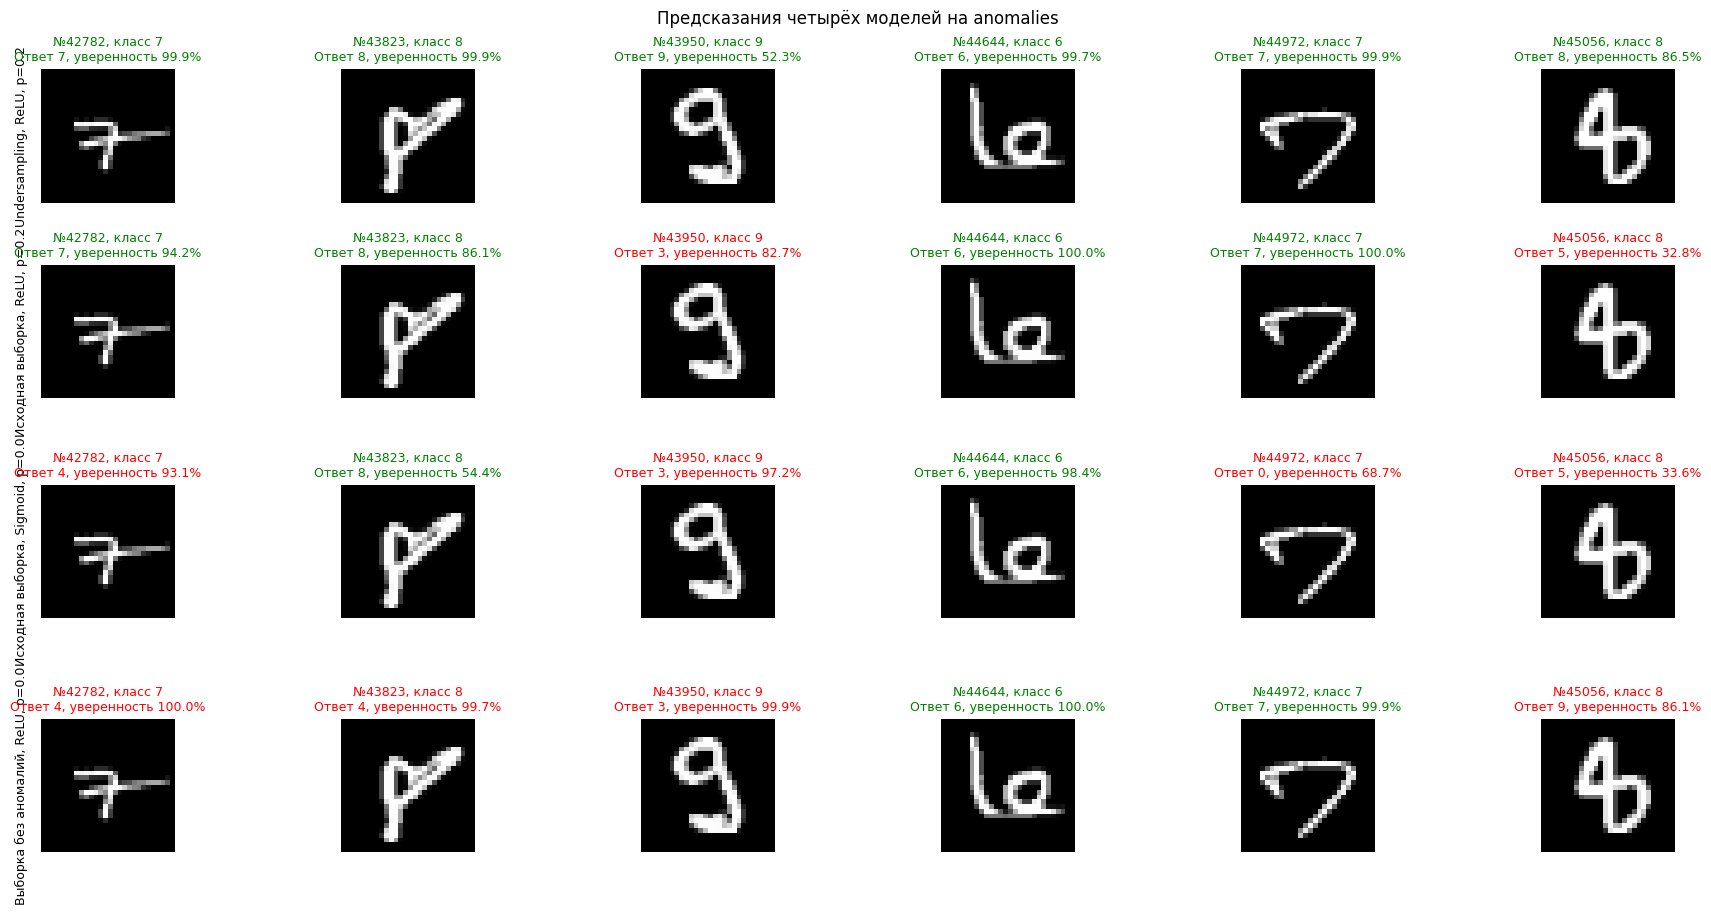

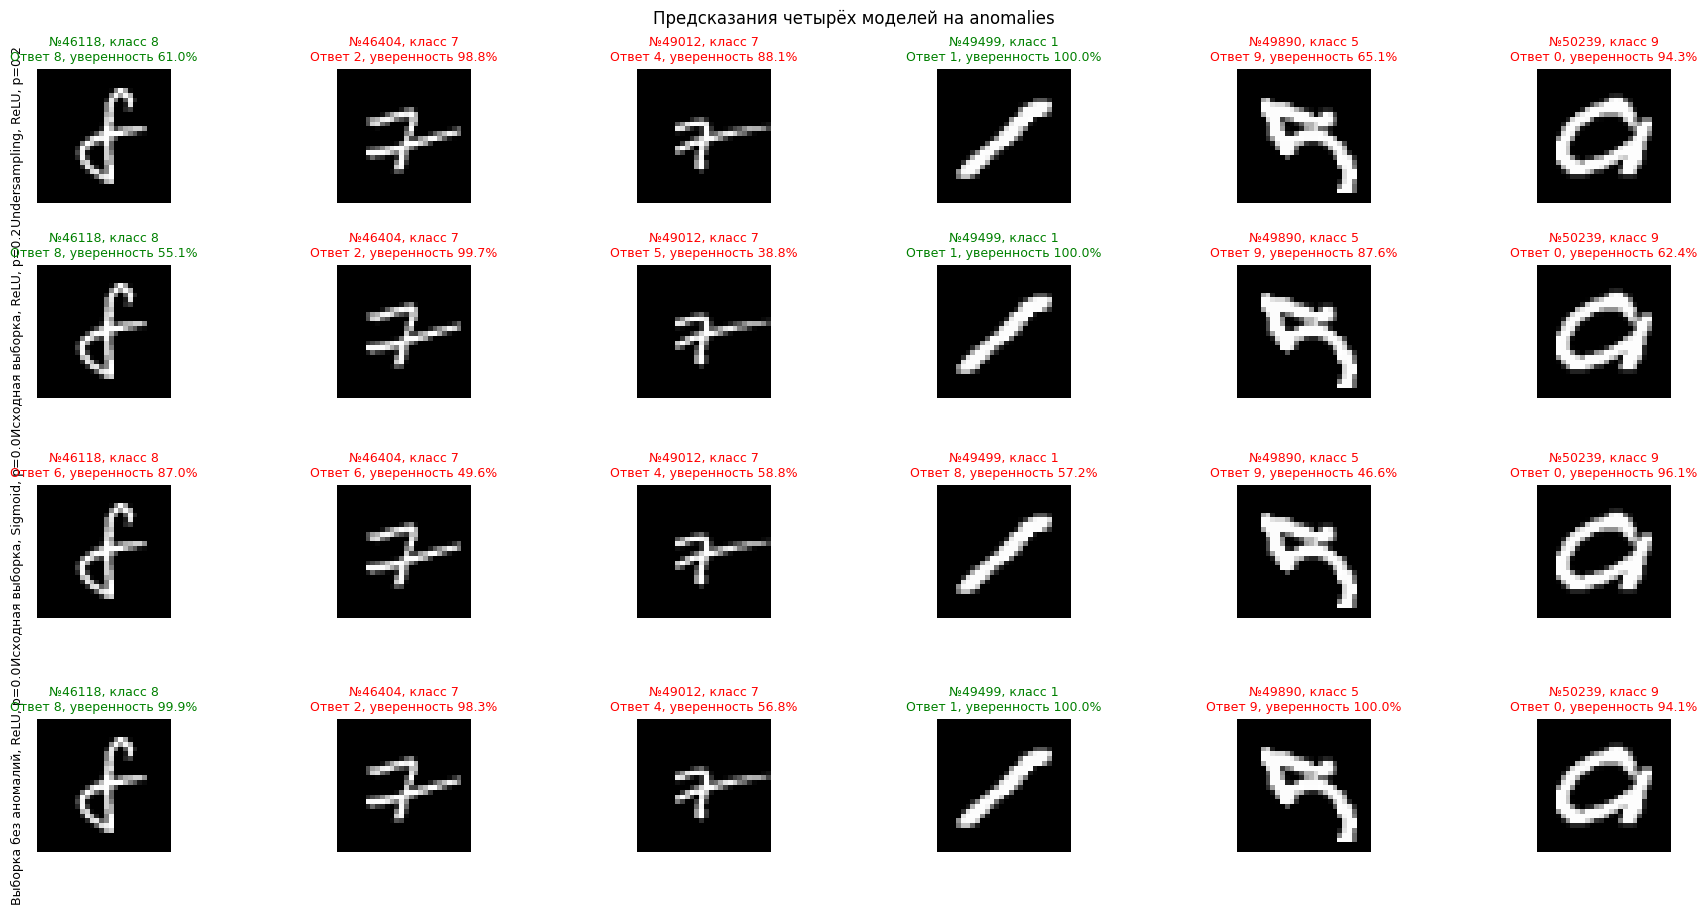

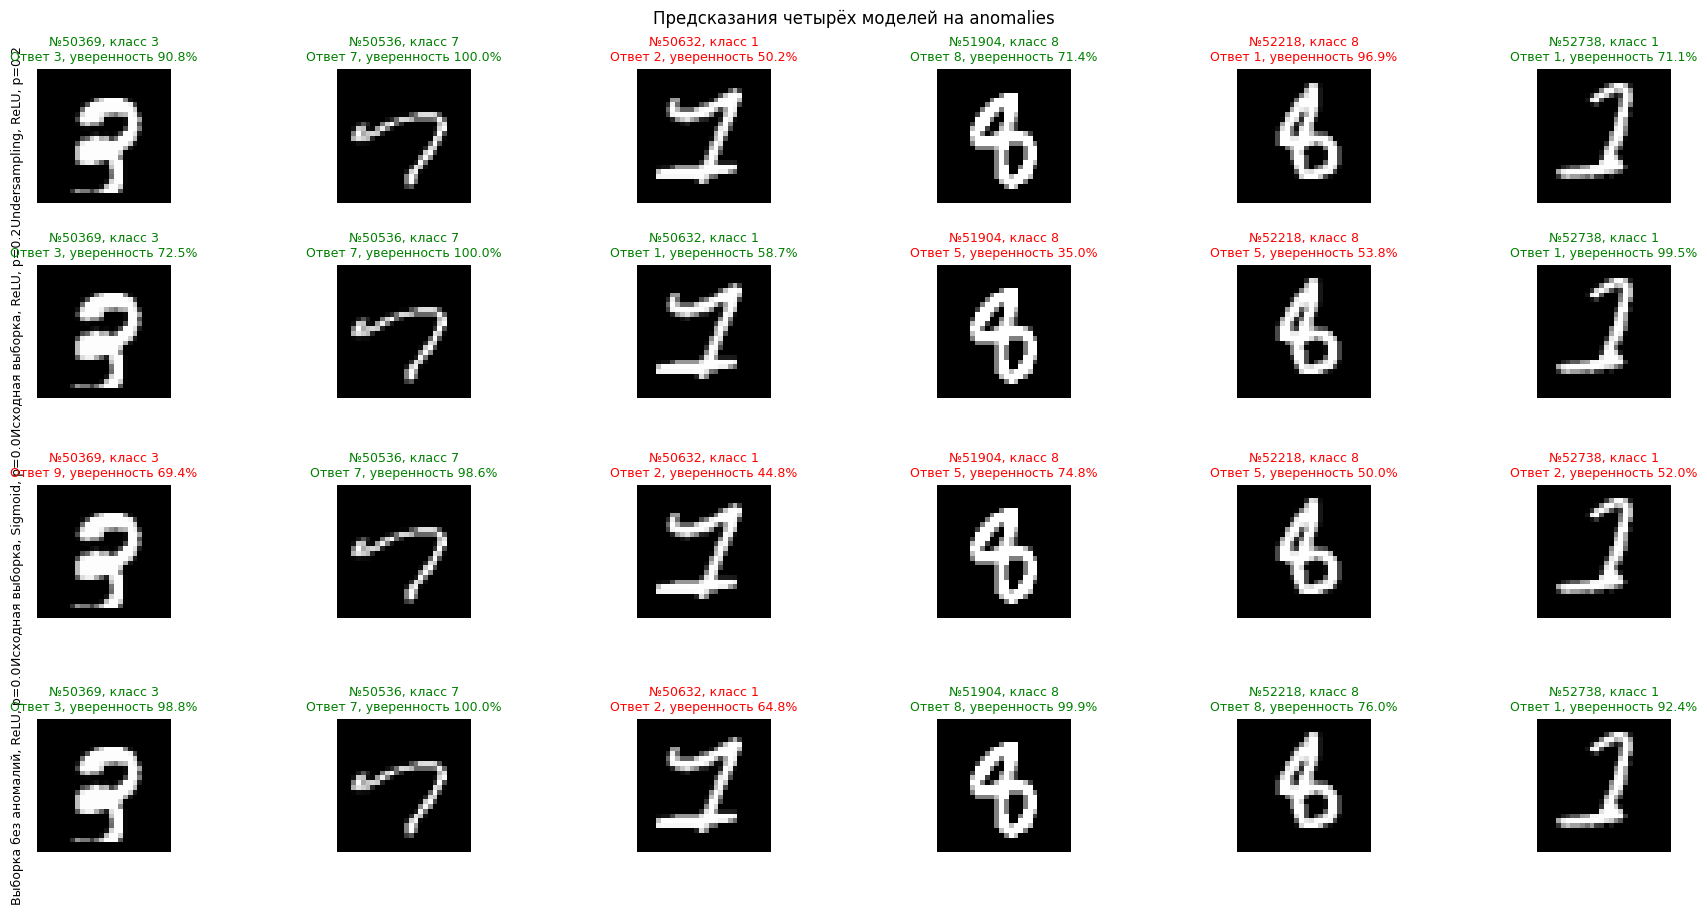

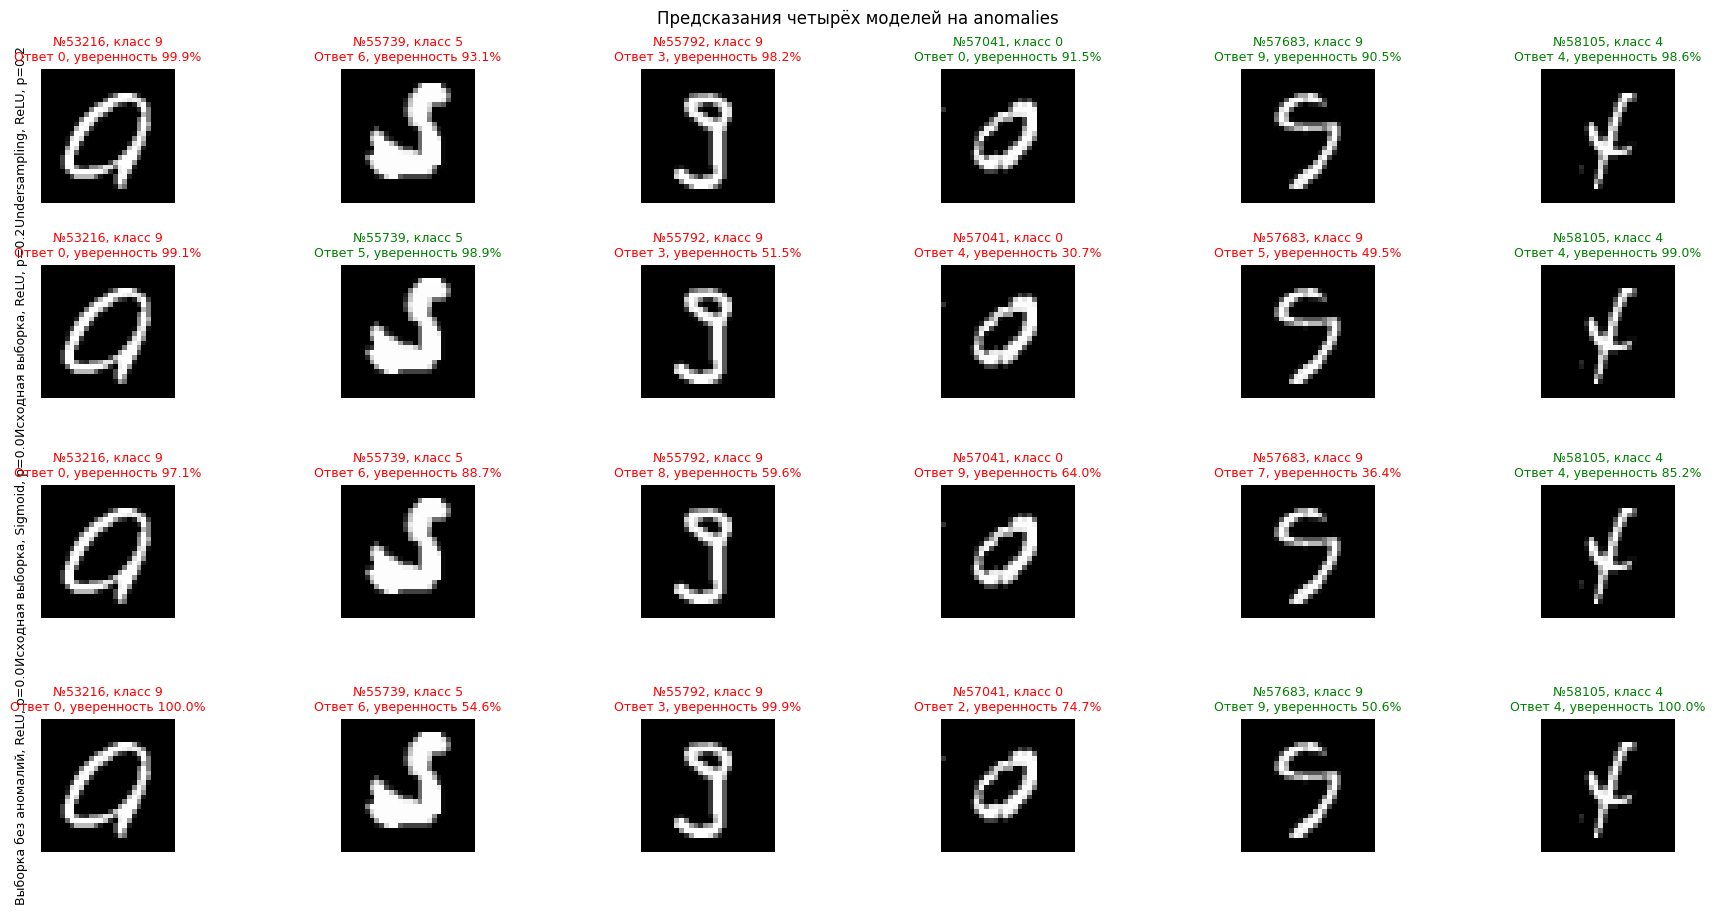

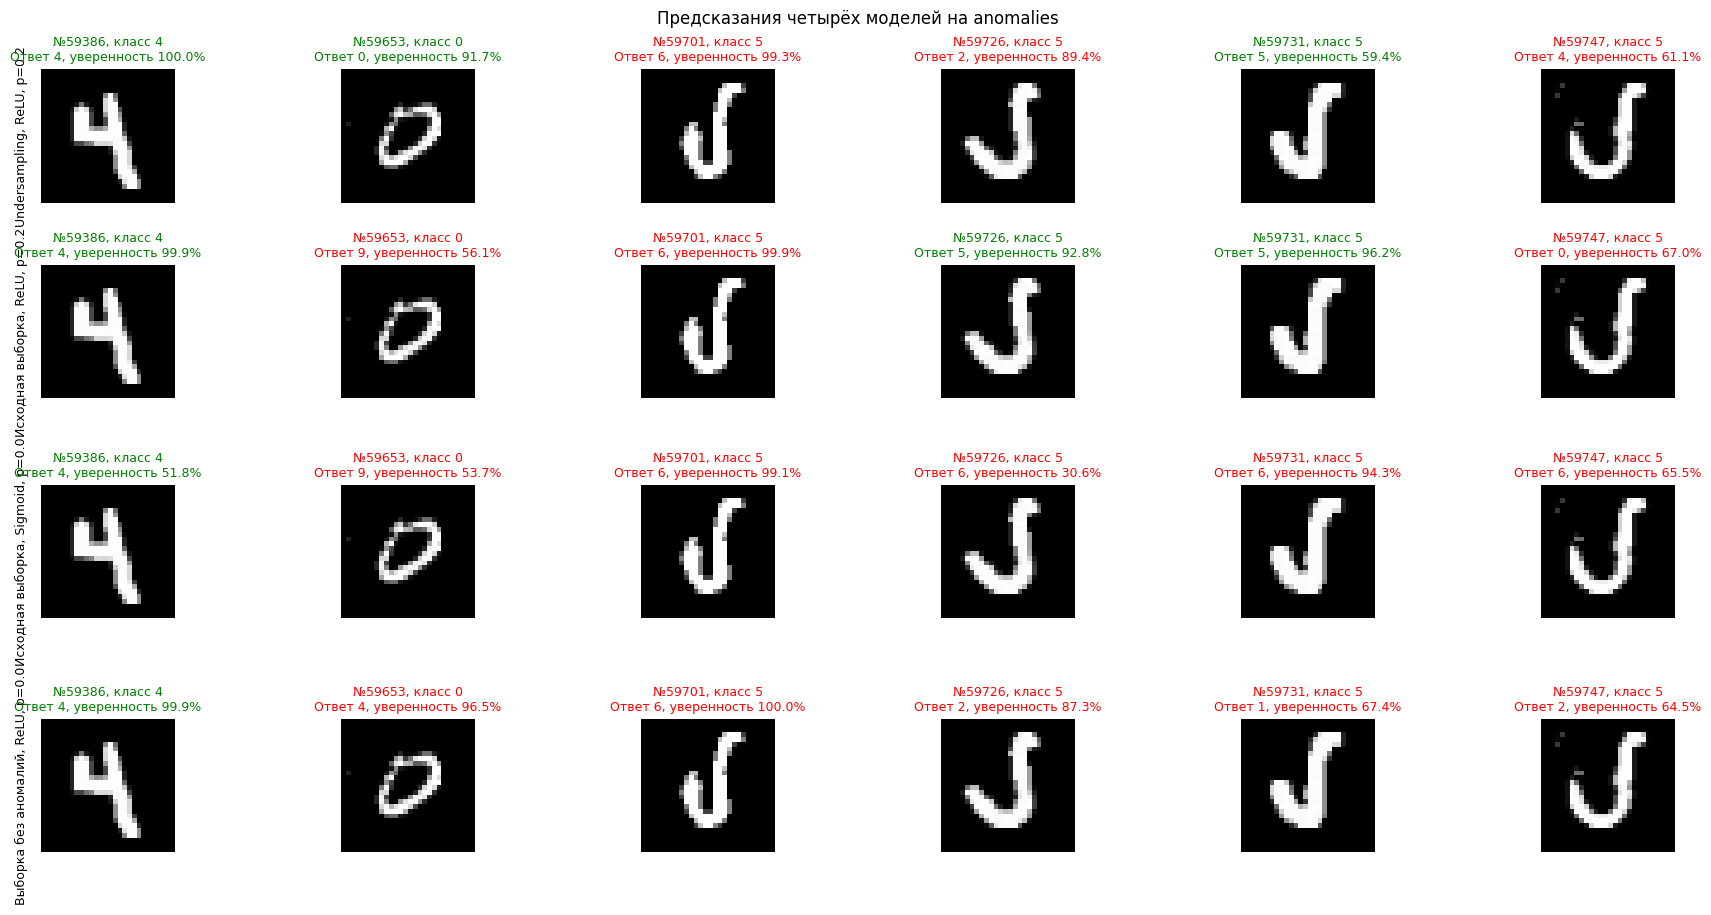

In [96]:
# Add here 3
from IPython.display import display

anomaly_models = {
    'Undersampling, ReLU, p=0.2': models_with_different_p_balanced[0],
    'Исходная выборка, ReLU, p=0.2': models_with_different_p[1],
    'Исходная выборка, Sigmoid, p=0.0': models_with_different_p_sigmoid[0],
    'Выборка без аномалий, ReLU, p=0.0': models_with_different_p_clean[0],
}
# Убираем служебный столбец и сохраняем порядок признаков обучения.
anomaly_images = anomalies.loc[:, X.columns].to_numpy(dtype=np.float32)
anomaly_targets = y.loc[anomalies.index].to_numpy(dtype=np.int64)
anomaly_predictions = {}
anomaly_results = pd.DataFrame({'Истинный класс': anomaly_targets}, index=anomalies.index)
anomaly_results.index.name = 'Индекс изображения'

if len(anomaly_images) == 0:
    print('В anomalies нет изображений.')
else:
    for model_name, anomaly_model in anomaly_models.items():
        parameter = next(anomaly_model.parameters())
        was_training = anomaly_model.training
        anomaly_model.eval()
        probabilities = []
        try:
            with torch.no_grad():
                for start in range(0, len(anomaly_images), 256):
                    batch = torch.as_tensor(
                        anomaly_images[start:start + 256],
                        dtype=parameter.dtype, device=parameter.device,
                    )
                    probabilities.append(torch.softmax(anomaly_model(batch), dim=1).cpu())
        finally:
            anomaly_model.train(was_training)
        confidence, predictions = torch.cat(probabilities).max(dim=1)
        predictions = predictions.numpy()
        confidence = confidence.numpy()
        correct = predictions == anomaly_targets
        anomaly_predictions[model_name] = {'predictions': predictions, 'confidence': confidence}
        anomaly_results[f'{model_name}: ответ'] = predictions
        anomaly_results[f'{model_name}: уверенность'] = confidence
        anomaly_results[f'{model_name}: верно'] = correct
        print(f'{model_name}: верно {correct.sum()}/{len(correct)}, accuracy={correct.mean():.1%}')
    display(anomaly_results)

    # Каждая строка — модель, каждый столбец — одно и то же изображение.
    # Показываем все аномалии страницами по шесть изображений.
    for start in range(0, len(anomaly_images), 6):
        indices = list(range(start, min(start + 6, len(anomaly_images))))
        fig, axes = plt.subplots(4, len(indices), figsize=(3 * len(indices), 9),
                                 squeeze=False, constrained_layout=True)
        fig.suptitle('Предсказания четырёх моделей на anomalies')
        for row, (model_name, result) in enumerate(anomaly_predictions.items()):
            for column, index in enumerate(indices):
                ax = axes[row, column]
                prediction = result['predictions'][index]
                ax.imshow(anomaly_images[index].reshape(28, 28), cmap='gray', vmin=0, vmax=255)
                ax.set_title(
                    f'№{anomalies.index[index]}, класс {anomaly_targets[index]}\n'
                    f'Ответ {prediction}, уверенность {result["confidence"][index]:.1%}',
                    color='green' if prediction == anomaly_targets[index] else 'red', fontsize=9,
                )
                ax.axis('off')
            axes[row, 0].text(-0.1, 0.5, model_name, transform=axes[row, 0].transAxes,
                              rotation=90, ha='right', va='center', fontsize=9)
        plt.show()


<Axes: >

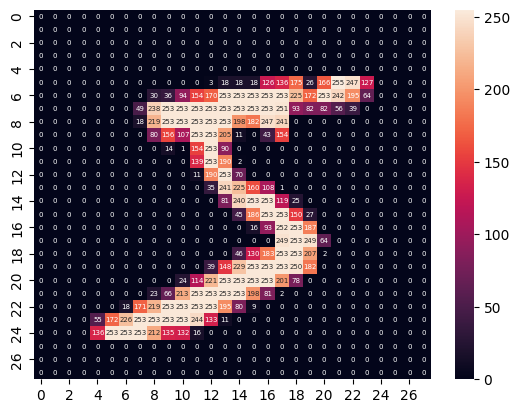

In [115]:
sns.heatmap(to_image(X.iloc[0]), annot=True, fmt="d",annot_kws={"size": 5})

In [116]:
models_with_different_p[0]

NeuralNetwork(
  (l1): Linear(in_features=784, out_features=64, bias=True)
  (l2): Linear(in_features=64, out_features=10, bias=True)
  (drop): Dropout(p=0.0, inplace=False)
  (activation_func): ReLU()
)